# Section 1.2.5 — Deuxièmes limites et MCRS

Ce notebook étudie les distributions conditionnelles des deuxièmes limites dans le modèle quatre files :

$$[Q^{+1}, Q^{-1}, Q^{+2}, Q^{-2}].$$

L'objectif scientifique principal n'est pas seulement d'estimer une probabilité de déplétion. Il est d'estimer et de comparer les lois conditionnelles

$$\mathrm{Law}(Q^{-2}\mid Q^{-1}=0),\qquad \mathrm{Law}(Q^{-2}\mid Q^{+1}=0),$$

afin de mesurer l'effet de l'excitation croisée sur la deuxième limite bid.

## 1.2.5.0 — MCRS : méthode, loi conditionnelle de S et diagnostics

Cette partie regroupe la conception de l'estimateur : convention de signe, état markovien $(Q,S)$, collecte frontière, loi conditionnelle de $S$, redémarrages locaux, diagnostics Ogata et comparaison distributionnelle. Les réponses finales aux deux sous-questions du sujet sont ensuite résumées en `1.2.5.1` et `1.2.5.2`.

La méthode utilisée est **Markovian Conditional Restart Splitting** (MCRS). Ogata thinning reste le simulateur bas niveau des trajectoires Hawkes. MCRS ajoute une couche d'estimation rare-event : on collecte des checkpoints proches de la frontière, puis on redémarre localement depuis l'état markovien complet.

La comparaison finale porte donc sur des métriques distributionnelles de $Q^{-2}$, plutôt que seulement sur la largeur d'intervalle de confiance d'un estimateur de Bernoulli.

Cette première partie sert donc de **chapitre méthodologique 1.2.5.0**. Les sections ajoutées à la fin répondent ensuite directement aux questions 1.2.5.1 et 1.2.5.2 du sujet.

In [1]:
import sys
sys.path.insert(0, '.')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from model.hawkes_4q import FourQueueParams
from model import FourQueueHawkesSimulator
from model.restart_splitting import (
    METHOD_NAME,
    bootstrap_difference_ci,
    bootstrap_mean_ci,
    collect_boundary_states,
    default_hawkes_burn_in,
    local_depletion_target_fn,
    local_recovery_fn,
    multilevel_markovian_restart_splitting,
    plot_conditional_S_marginals,
    plot_conditional_S_pairwise,
    restart_from_boundary_distribution,
    run_naive_boundary_mc,
    run_naive_depletion_monte_carlo,
    summarize_conditional_S,
)
from model.plotting_utils import format_metric_table

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 42
QUEUE_INDICES = [1, -1, 2, -2]

BASE_CFG = dict(
    mu_plus_1=1.2,
    mu_minus_1=1.5,
    alpha=0.3,
    beta=0.5,
    mu_plus_2=0.8,
    mu_minus_2=0.6,
    b_cross=0.5,
    q1_init=10,
    q_neg1_init=10,
    q2_init=5,
    q_neg2_init=5,
)

A_VALUES = [0.0, 0.2, 0.5, 0.8, 1.2]
LEVELS = [8, 6, 4, 2, 1, 0]
N_BOUNDARY_PATHS = 300
N_RESTARTS = 1_000
HORIZON_BOUNDARY = 120.0
HORIZON_LOCAL = 25.0
RECOVERY_LEVEL = 2
BOOTSTRAP_REPS = 1_000

BURN_IN = default_hawkes_burn_in(FourQueueHawkesSimulator(FourQueueParams(**BASE_CFG, a_cross=0.0)))

pd.Series({**BASE_CFG, 'burn_in': BURN_IN, 'method': METHOD_NAME}, name='configuration')

mu_plus_1                                          1.2
mu_minus_1                                         1.5
alpha                                              0.3
beta                                               0.5
mu_plus_2                                          0.8
mu_minus_2                                         0.6
b_cross                                            0.5
q1_init                                             10
q_neg1_init                                         10
q2_init                                              5
q_neg2_init                                          5
burn_in                                           50.0
method         Markovian Conditional Restart Splitting
Name: configuration, dtype: object

### 1.2.5.0(a) Convention de signe et état markovien

La convention de signe du code est :

- indice positif : côté ask ;
- indice négatif : côté bid ;
- ordre d'état : $[Q^{+1}, Q^{-1}, Q^{+2}, Q^{-2}]$.

Pour Hawkes exponentiel, la dynamique est markovienne dans l'état augmenté $(N,S)$, où $N$ contient les tailles de files et $S$ l'excitation exponentiellement décayée. Dans le modèle quatre files, le vecteur utilisé ici est

$$
S=(S^{+1,-}, S^{-1,-}, S^{+1,-\to +2,+}, S^{-1,-\to -2,-}).
$$

La composante $S^{-1,-\to -2,-}$ correspond au canal bid demandé ici : les retraits sur $Q^{-1}$ pilotent la réponse de la deuxième limite $Q^{-2}$ dans le checkpoint markovien.

### 1.2.5.0(b) Principe de Markovian Conditional Restart Splitting

MCRS procède en deux étapes.

1. **Collecte frontière.** On simule des trajectoires Ogata jusqu'au premier temps où $Q^{\pm1}=1$. Le checkpoint stocke le temps, les queues, l'intensité, $H$, $G$ et les métadonnées.

2. **Redémarrage conditionnel.** On échantillonne ces checkpoints et on continue localement jusqu'à déplétion, récupération ou timeout. La probabilité locale estimée est

$$
\widehat p=\frac{1}{R}\sum_{r=1}^R
\mathbf 1\{Q^{\pm1}\text{ atteint }0\text{ avant récupération}\}.
$$

Mais en Section 1.2.5, l'objet central est la distribution des valeurs de $Q^{-2}$ au moment des redémarrages réussis.

### 1.2.5.0(c) Interprétation théorique des indicateurs

- `success_probability` : probabilité empirique qu'après redémarrage depuis $Q^{\pm1}=1$, la trajectoire atteigne $Q^{\pm1}=0$ avant récupération. Formule : $\widehat p=R^{-1}\sum_r \mathbf 1_{\{\tau_0<\tau_{rec}\}}$.
- `recovery_probability` : probabilité que la trajectoire s'éloigne de la frontière, par exemple $Q^{\pm1}\ge$ `recovery_level`, avant d'atteindre zéro.
- `timeout_probability` : probabilité que ni déplétion ni récupération ne se produise avant `HORIZON_LOCAL`; si elle est grande, l'horizon local est trop court.
- `std_error_success` : erreur standard Bernoulli $\sqrt{\widehat p(1-\widehat p)/R}$. Si $\widehat p=1$, elle vaut zéro et ne mesure pas l'incertitude distributionnelle.
- `mean_Q-2_success` : estimateur de $\mathbb E[Q^{-2}\mid$ déplétion locale réussie$]$, l'objet central de cette section.
- `bootstrap CI` : intervalle obtenu par rééchantillonnage des valeurs réussies de $Q^{-2}$; il est plus pertinent qu'un IC Bernoulli lorsque $\widehat p$ est dégénéré.
- `effective_sample_size` : nombre effectif d'échantillons indépendants représentés par le schéma de rééchantillonnage.
- `checkpoint_usage_ess` : diagnostic de diversité des checkpoints; si quelques checkpoints sont trop réutilisés, l'ESS devient petit.
- `acceptance_candidate_ratio` : efficacité d'Ogata, égale à `accepted_events / candidate_events`.
- `cpu_seconds` : coût mur en secondes.
- `ESS_per_second` : efficacité computationnelle, `effective_sample_size / cpu_seconds`.
- `n_events` et `n_candidates` : proxys indépendants du matériel pour mesurer le coût de simulation.
- `avg_local_time` : temps simulé moyen après redémarrage avant déplétion, récupération ou timeout.
- `a_cross` : amplitude de l'excitation des arrivées en deuxième limite par les retraits en première limite; l'augmenter doit déplacer $Q^{-2}_{same}$ vers la droite.
- `burn_in` : période préliminaire qui réduit les effets de bord en laissant les excitations Hawkes se rapprocher d'un régime stationnaire.
- `levels` : niveaux de splitting $Q=10\to8\to6\to4\to2\to1\to0$; le produit des probabilités conditionnelles estime la probabilité d'atteindre zéro.

**cpu_seconds_per_sample et cpu_seconds_per_effective_sample.** Ces ratios mesurent le coût moyen par échantillon brut et par échantillon effectif. Le second est plus sévère pour MCRS, car il pénalise la réutilisation répétée des mêmes checkpoints frontière.

### 1.2.5.0(d) Configuration et paramètres

Le burn-in par défaut est

$$T_{burn}=\frac{10}{\beta(1-\alpha/\beta)}.$$

Avec $\alpha=0.3$ et $\beta=0.5$, on obtient $T_{burn}=50$. Ce burn-in est utilisé pour la collecte frontière principale.

In [2]:
def make_params(a_cross: float, q0: int = 10) -> FourQueueParams:
    return FourQueueParams(
        **dict(BASE_CFG, q1_init=q0, q_neg1_init=q0),
        a_cross=float(a_cross),
    )


def q_label(queue_index: int) -> str:
    return 'Q+1' if queue_index == 1 else 'Q-1'


def resume_distribution(x):
    x = np.asarray(x, dtype=float)
    return pd.Series({
        'n_samples': int(len(x)),
        'mean_Q_minus_2': float(np.mean(x)) if len(x) else np.nan,
        'std_Q_minus_2': float(np.std(x, ddof=1)) if len(x) > 1 else np.nan,
        'q05': float(np.quantile(x, 0.05)) if len(x) else np.nan,
        'median': float(np.quantile(x, 0.50)) if len(x) else np.nan,
        'q95': float(np.quantile(x, 0.95)) if len(x) else np.nan,
    })


def ci_width(ci):
    if ci is None:
        return np.nan
    lo, hi = ci
    return hi - lo if np.isfinite(lo) and np.isfinite(hi) else np.nan


def q_neg2_success_from_result(result):
    return np.asarray(result.observables.get('q_neg2_success', np.empty(0)), dtype=float)


def q_neg2_success(bundle):
    return q_neg2_success_from_result(bundle['result'])


def run_mcrs_side(params, queue_index, seed, n_boundary_paths=N_BOUNDARY_PATHS, n_restarts=N_RESTARTS,
                  horizon_boundary=HORIZON_BOUNDARY, horizon_local=HORIZON_LOCAL, burn_in=BURN_IN):
    simulator = FourQueueHawkesSimulator(params)
    initial_state = [params.q1_init, params.q_neg1_init, params.q2_init, params.q_neg2_init]
    sample = collect_boundary_states(
        simulator=simulator,
        initial_state=initial_state,
        horizon=horizon_boundary,
        n_paths=n_boundary_paths,
        rng=seed,
        burn_in=burn_in,
        queue_index=queue_index,
        boundary_level=1,
        queue_indices=QUEUE_INDICES,
        boundary_name=f'{q_label(queue_index)}=1',
        queue_label=q_label(queue_index),
    )
    result = restart_from_boundary_distribution(
        checkpoints=sample,
        simulator=simulator,
        local_target_fn=local_depletion_target_fn(queue_index),
        recovery_fn=local_recovery_fn(queue_index, RECOVERY_LEVEL),
        horizon_local=horizon_local,
        n_restarts=n_restarts,
        rng=seed + 1_000_003,
        sample_with_replacement=True,
        record_path=False,
    )
    return {'method': METHOD_NAME, 'params': params, 'queue_index': queue_index,
            'simulator': simulator, 'boundary_sample': sample, 'result': result}


def run_naive_boundary_side(params, queue_index, seed, n_paths, horizon_boundary=HORIZON_BOUNDARY,
                            horizon_local=HORIZON_LOCAL, burn_in=BURN_IN):
    simulator = FourQueueHawkesSimulator(params)
    result = run_naive_boundary_mc(
        simulator=simulator,
        initial_state=[params.q1_init, params.q_neg1_init, params.q2_init, params.q_neg2_init],
        queue_index=queue_index,
        horizon=horizon_boundary,
        n_paths=n_paths,
        horizon_local=horizon_local,
        rng=seed,
        boundary_level=1,
        recovery_level=RECOVERY_LEVEL,
        burn_in=burn_in,
        queue_indices=QUEUE_INDICES,
    )
    return {'method': 'Naive Ogata Monte Carlo', 'params': params, 'queue_index': queue_index, 'result': result}


def total_cpu_seconds(obj):
    result = obj['result']
    diag = result.diagnostics
    boundary_meta = diag.get('boundary_metadata', {})
    if 'boundary_sample' in obj:
        boundary_meta = obj['boundary_sample'].metadata
    return float(diag.get('cpu_seconds', 0.0) + boundary_meta.get('cpu_seconds', 0.0))


def total_events_candidates(obj):
    result = obj['result']
    diag = result.diagnostics
    boundary_meta = diag.get('boundary_metadata', {})
    if 'boundary_sample' in obj:
        boundary_meta = obj['boundary_sample'].metadata
    n_events = int(diag.get('n_events', 0) + boundary_meta.get('n_events', 0))
    n_candidates = int(diag.get('n_candidates', 0) + boundary_meta.get('n_candidates', 0))
    return n_events, n_candidates


def effective_sample_size(obj):
    result = obj['result']
    diag = result.diagnostics
    if obj['method'] == 'Naive Ogata Monte Carlo':
        return float(len(q_neg2_success_from_result(result)))
    return float(diag.get('checkpoint_usage_effective_sample_size', np.nan))


def distributional_metrics(obj, side, seed=SEED):
    result = obj['result']
    q = q_neg2_success_from_result(result)
    stats = resume_distribution(q).to_dict()
    mean_ci = bootstrap_mean_ci(q, n_bootstrap=BOOTSTRAP_REPS, rng=seed) if len(q) else (np.nan, np.nan)
    n_events, n_candidates = total_events_candidates(obj)
    cpu = total_cpu_seconds(obj)
    ess = effective_sample_size(obj)
    diag = result.diagnostics
    checkpoint_usage_ess = diag.get('checkpoint_usage_effective_sample_size', np.nan)
    bootstrap_width = mean_ci[1] - mean_ci[0] if np.isfinite(mean_ci[0]) and np.isfinite(mean_ci[1]) else np.nan
    row = {
        'method': obj['method'],
        'side': side,
        'a_cross': getattr(obj.get('params', None), 'a_cross', np.nan),
        **stats,
        'bootstrap_ci_low': mean_ci[0],
        'bootstrap_ci_high': mean_ci[1],
        'bootstrap_ci_width': bootstrap_width,
        'mean_ci_low': mean_ci[0],
        'mean_ci_high': mean_ci[1],
        'bootstrap_CI_width_mean_Q_minus_2': bootstrap_width,
        'effective_sample_size': ess,
        'checkpoint_usage_ess': checkpoint_usage_ess,
        'cpu_seconds': cpu,
        'ESS_per_second': ess / cpu if cpu > 0 else np.nan,
        'cpu_seconds_per_sample': cpu / len(q) if len(q) > 0 else np.nan,
        'cpu_seconds_per_effective_sample': cpu / ess if ess > 0 else np.nan,
        'n_events': n_events,
        'n_candidates': n_candidates,
        'acceptance_candidate_ratio': n_events / n_candidates if n_candidates > 0 else np.nan,
        'success_probability': diag.get('success_probability', result.probability_estimate),
        'recovery_probability': diag.get('recovery_probability', np.nan),
        'timeout_probability': diag.get('timeout_probability', np.nan),
        'avg_local_time': diag.get('average_local_simulation_time', np.nan),
    }
    return row


def conditional_S_table(sample):
    names = sample.metadata.get('S_component_names', [])
    summary = summarize_conditional_S(sample.S_samples, names)
    rows = []
    for j, name in enumerate(names):
        rows.append({
            'component': name,
            'mean': summary['mean'][j],
            'std': summary['std'][j],
            'q05': summary['quantiles'][0.05][j],
            'median': summary['quantiles'][0.50][j],
            'q95': summary['quantiles'][0.95][j],
        })
    return pd.DataFrame(rows).set_index('component') if rows else pd.DataFrame()


def safe_barplot_metric(df, x, y, group=None, title=None, zero_policy='annotate', ylabel=None):
    data = df.copy()
    if data[y].isna().any():
        warnings.warn(f'Missing values in {y}; dropping NaN rows.')
        data = data.dropna(subset=[y])
    fig, ax = plt.subplots(figsize=(12, 4.8))
    if data.empty:
        ax.text(0.5, 0.5, f'No finite values for {y}', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return fig, ax
    if np.allclose(data[y].to_numpy(dtype=float), 0.0):
        message = (
            'All CI widths are zero because all estimated probabilities are equal to one.\n'
            'The event is not rare under the current configuration; compare conditional\n'
            'distribution metrics instead.'
        )
        print('Degenerate probability estimator: p=1 for all methods. Switching to distributional comparison.')
        if zero_policy == 'annotate':
            ax.text(0.5, 0.5, message, ha='center', va='center', wrap=True, transform=ax.transAxes)
            ax.set_title(title or y)
            ax.set_axis_off()
            return fig, ax
    labels = data[x].astype(str) if group is None else data[x].astype(str) + ' | ' + data[group].astype(str)
    bars = ax.bar(labels, data[y].to_numpy(dtype=float), color='tab:blue')
    ax.set_title(title or y)
    ax.set_ylabel(ylabel or y)
    if max(len(str(label)) for label in labels) > 12:
        ax.tick_params(axis='x', rotation=20)
    for bar, value in zip(bars, data[y]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.3g}', ha='center', va='bottom')
    fig.tight_layout()
    return fig, ax


def joint_distribution_plot(x, y, hue=None, kind='hexbin', title=None, xlabel=None, ylabel=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    fig, ax = plt.subplots(figsize=(8, 5))
    if len(x) == 0:
        ax.text(0.5, 0.5, 'No paired finite samples', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return fig, ax
    corr = np.corrcoef(x, y)[0, 1] if len(x) > 1 and np.std(x) > 0 and np.std(y) > 0 else np.nan
    if hue is None:
        if kind == 'hexbin' and len(x) >= 300:
            hb = ax.hexbin(x, y, gridsize=28, mincnt=1, cmap='viridis')
            fig.colorbar(hb, ax=ax, label='count')
        else:
            ax.scatter(x, y, alpha=0.55, s=20)
    else:
        hue = np.asarray(hue)[mask]
        for label in pd.unique(hue):
            m = hue == label
            ax.scatter(x[m], y[m], alpha=0.35, s=16, label=str(label))
        ax.legend()
    ax.set_xlabel(xlabel or 'x')
    ax.set_ylabel(ylabel or 'y')
    ax.set_title((title or 'Joint distribution') + f' | corr={corr:.3f}' if np.isfinite(corr) else (title or 'Joint distribution'))
    fig.tight_layout()
    return fig, ax


def restart_content_table(obj, n=8):
    result = obj['result']
    obs = result.observables
    names = obj.get('boundary_sample', {}).metadata.get('S_component_names', []) if 'boundary_sample' in obj else []
    rows = []
    for k in range(min(n, len(obs['success']))):
        row = {
            'restart': k,
            'outcome': obs.get('outcome', np.array([''] * len(obs['success'])))[k],
            'local_time': obs['local_times'][k],
            'start_Q+1': obs['start_queues'][k, 0],
            'start_Q-1': obs['start_queues'][k, 1],
            'start_Q-2': obs['start_queues'][k, 3],
            'final_Q+1': obs['final_queues'][k, 0],
            'final_Q-1': obs['final_queues'][k, 1],
            'final_Q-2': obs['final_queues'][k, 3],
        }
        for j, name in enumerate(names):
            row[f'start {name}'] = obs['start_S'][k, j]
            row[f'end {name}'] = obs['end_S'][k, j]
        rows.append(row)
    return pd.DataFrame(rows)


def display_fr(text):
    display(Markdown(text))


### 1.2.5.0(e) Collecte des checkpoints frontière avec burn-in

On commence par collecter des états frontière avec $a_{cross}=0.5$. La frontière $Q^{-1}=1$ sert à étudier le côté same-side bid; la frontière $Q^{+1}=1$ sert de comparaison opposite-side pour $Q^{-2}$.

In [3]:
params_ref = make_params(a_cross=0.5)
ref_same = run_mcrs_side(params_ref, queue_index=-1, seed=SEED + 10)
ref_opp = run_mcrs_side(params_ref, queue_index=1, seed=SEED + 20)

boundary_table = pd.DataFrame([
    {
        'side': 'Q-1=1 boundary',
        'n_paths': ref_same['boundary_sample'].metadata['n_paths'],
        'n_boundary_samples': ref_same['boundary_sample'].metadata['n_boundary_hits'],
        'boundary_hit_rate': ref_same['boundary_sample'].metadata['boundary_hit_rate'],
        'burn_in': ref_same['boundary_sample'].metadata['burn_in'],
        'cpu_seconds': ref_same['boundary_sample'].metadata['cpu_seconds'],
        'n_events': ref_same['boundary_sample'].metadata['n_events'],
        'n_candidates': ref_same['boundary_sample'].metadata['n_candidates'],
    },
    {
        'side': 'Q+1=1 boundary',
        'n_paths': ref_opp['boundary_sample'].metadata['n_paths'],
        'n_boundary_samples': ref_opp['boundary_sample'].metadata['n_boundary_hits'],
        'boundary_hit_rate': ref_opp['boundary_sample'].metadata['boundary_hit_rate'],
        'burn_in': ref_opp['boundary_sample'].metadata['burn_in'],
        'cpu_seconds': ref_opp['boundary_sample'].metadata['cpu_seconds'],
        'n_events': ref_opp['boundary_sample'].metadata['n_events'],
        'n_candidates': ref_opp['boundary_sample'].metadata['n_candidates'],
    },
])
display(boundary_table)

display_fr(
    f"""
**Interprétation.** Les deux collectes utilisent un burn-in de {BURN_IN:.0f}. 
On obtient {int(boundary_table.loc[0, 'n_boundary_samples'])} checkpoints bid et {int(boundary_table.loc[1, 'n_boundary_samples'])} checkpoints ask.
Le taux d'atteinte frontière vaut respectivement {boundary_table.loc[0, 'boundary_hit_rate']:.3f} et {boundary_table.loc[1, 'boundary_hit_rate']:.3f}.
Ces checkpoints forment l'approximation empirique de $Law(S\\mid Q^{{-1}}=1)$ et $Law(S\\mid Q^{{+1}}=1)$.
"""
)


,side,n_paths,n_boundary_samples,boundary_hit_rate,burn_in,cpu_seconds,n_events,n_candidates
0,Q-1=1 boundary,300,300,1.0,50.0,2.289918,1083,1108
1,Q+1=1 boundary,300,300,1.0,50.0,1.906936,1410,1449



**Interprétation.** Les deux collectes utilisent un burn-in de 50. 
On obtient 300 checkpoints bid et 300 checkpoints ask.
Le taux d'atteinte frontière vaut respectivement 1.000 et 1.000.
Ces checkpoints forment l'approximation empirique de $Law(S\mid Q^{-1}=1)$ et $Law(S\mid Q^{+1}=1)$.


### 1.2.5.0(f) Loi conditionnelle de S à la frontière

Les tableaux et cartes de chaleur suivants décrivent la loi conditionnelle empirique de l'excitation Hawkes au voisinage de la déplétion. Ils permettent de vérifier que les redémarrages conservent bien la mémoire Hawkes.

mean       std       q05    median  \
               component                                                  
Law(S | Q-1=1) S^{+1,-}          1.515757  0.775656  0.304396  1.475860   
               S^{-1,-}          1.701139  0.696575  0.713355  1.651115   
               S^{+1,- -> +2,+}  1.279093  0.615587  0.480615  1.199732   
               S^{-1,- -> -2,-}  1.401655  0.686404  0.434878  1.304557   
Law(S | Q+1=1) S^{+1,-}          1.757045  0.684875  0.668410  1.745146   
               S^{-1,-}          1.593878  0.799328  0.435685  1.523019   
               S^{+1,- -> +2,+}  1.493515  0.748092  0.509738  1.399453   
               S^{-1,- -> -2,-}  1.298921  0.576141  0.412945  1.299347   

                                      q95  
               component                   
Law(S | Q-1=1) S^{+1,-}          2.784230  
               S^{-1,-}          2.863328  
               S^{+1,- -> +2,+}  2.340151  
               S^{-1,- -> -2,-}  2.532080  
Law(S | Q+1=1) S^{+1,-}          2.896362  
               S^{-1,-}          3.082836  
               S^{+1,- -> +2,+}  2.803117  
               S^{-1,- -> -2,-}  2.287925

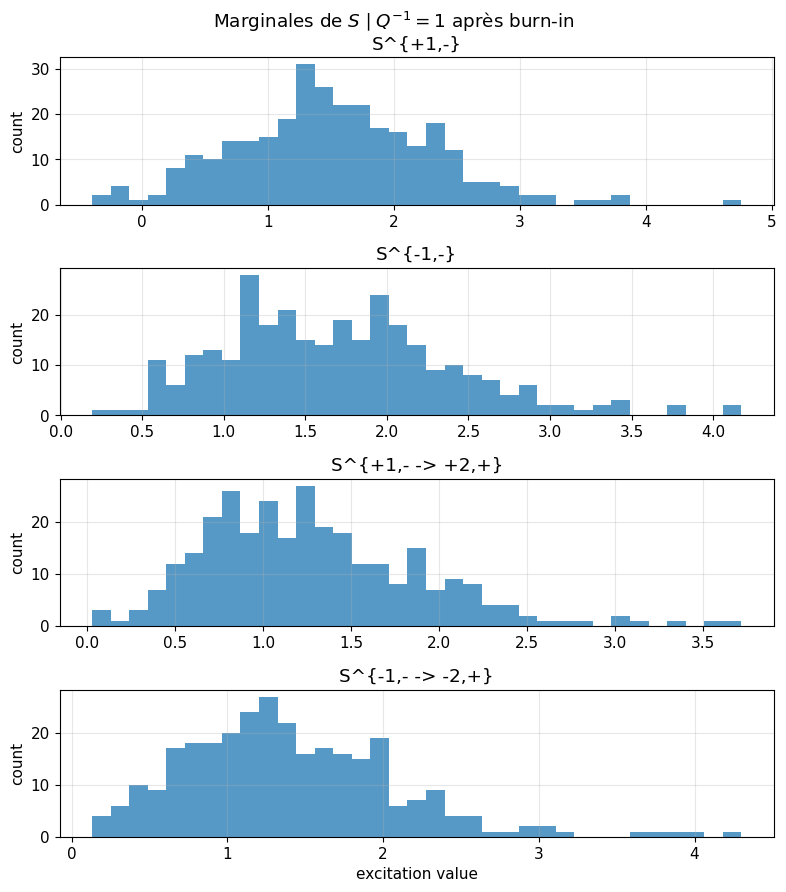

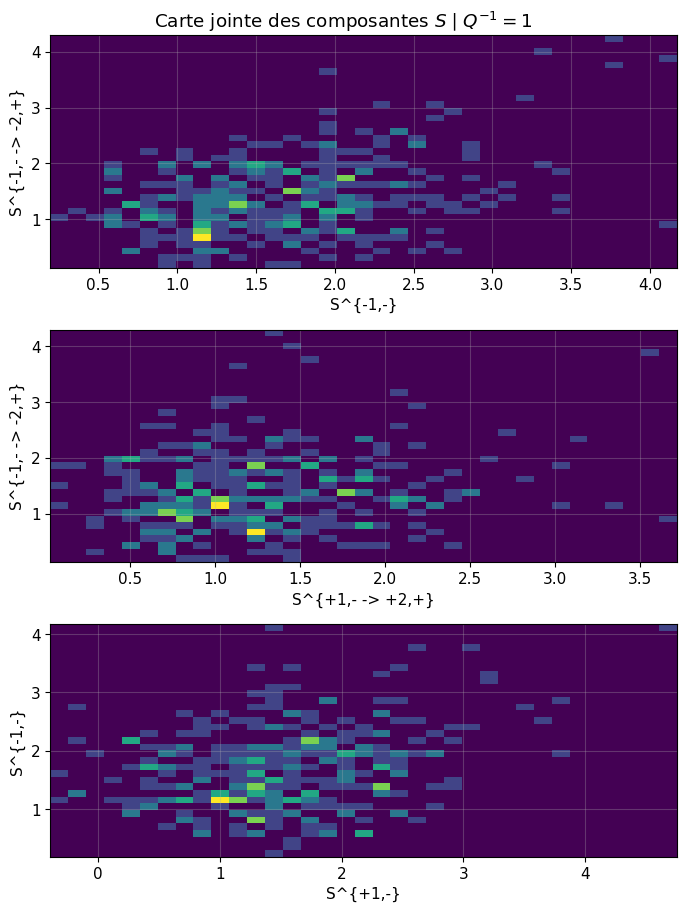


**Interprétation de la loi jointe de S.** Ce graphique montre la relation empirique entre les excitations de première limite et les composantes de replenishment de deuxième limite.
Pour $Q^{-1}=1$, la moyenne de $S^{-1,-	o -2,-}$ vaut 1.402 et son quantile 95 % vaut 2.532.
Pour $Q^{+1}=1$, la moyenne ask $S^{+1,-	o +2,+}$ vaut 1.494.
Une masse importante dans la composante bid indique que les retraits récents de $Q^{-1}$ ont déjà activé l'arrivée sur $Q^{-2}$ avant le redémarrage.


In [4]:
S_same_table = conditional_S_table(ref_same['boundary_sample'])
S_opp_table = conditional_S_table(ref_opp['boundary_sample'])
display(pd.concat({'Law(S | Q-1=1)': S_same_table, 'Law(S | Q+1=1)': S_opp_table}))

names_same = ref_same['boundary_sample'].metadata['S_component_names']
fig, _ = plot_conditional_S_marginals(ref_same['boundary_sample'].S_samples, names_same, bins=35)
fig.suptitle(r'Marginales de $S\mid Q^{-1}=1$ après burn-in', y=1.01)
plt.show()

fig, _ = plot_conditional_S_pairwise(
    ref_same['boundary_sample'].S_samples,
    names_same,
    pairs=[(1, 3), (2, 3), (0, 1)],
    bins=35,
)
fig.suptitle(r'Carte jointe des composantes $S\mid Q^{-1}=1$', y=1.01)
plt.show()

bid_cross_mean = S_same_table.loc['S^{-1,- -> -2,-}', 'mean']
bid_cross_q95 = S_same_table.loc['S^{-1,- -> -2,-}', 'q95']
ask_cross_mean = S_opp_table.loc['S^{+1,- -> +2,+}', 'mean']

display_fr(
    f"""
**Interprétation de la loi jointe de S.** Ce graphique montre la relation empirique entre les excitations de première limite et les composantes de replenishment de deuxième limite.
Pour $Q^{{-1}}=1$, la moyenne de $S^{{-1,-\to -2,-}}$ vaut {bid_cross_mean:.3f} et son quantile 95 % vaut {bid_cross_q95:.3f}.
Pour $Q^{{+1}}=1$, la moyenne ask $S^{{+1,-\to +2,+}}$ vaut {ask_cross_mean:.3f}.
Une masse importante dans la composante bid indique que les retraits récents de $Q^{{-1}}$ ont déjà activé l'arrivée sur $Q^{{-2}}$ avant le redémarrage.
"""
)


### 1.2.5.0(g) Diagnostic burn-in

Pour vérifier l'effet du burn-in, on compare la loi de $S$ à la frontière $Q^{-1}=1$ avec et sans période préliminaire. Le modèle n'est pas modifié; seul l'état initial de l'excitation Hawkes change.

In [5]:
no_burn_sample = collect_boundary_states(
    simulator=FourQueueHawkesSimulator(params_ref),
    initial_state=[params_ref.q1_init, params_ref.q_neg1_init, params_ref.q2_init, params_ref.q_neg2_init],
    horizon=HORIZON_BOUNDARY,
    n_paths=200,
    rng=SEED + 303,
    burn_in=0.0,
    queue_index=-1,
    boundary_level=1,
    queue_indices=QUEUE_INDICES,
    boundary_name='Q-1=1 no burn-in',
    queue_label='Q-1',
)

burn_compare = pd.DataFrame({
    'no_burn_in_mean': conditional_S_table(no_burn_sample)['mean'],
    'burn_in_50_mean': conditional_S_table(ref_same['boundary_sample'])['mean'],
    'no_burn_in_std': conditional_S_table(no_burn_sample)['std'],
    'burn_in_50_std': conditional_S_table(ref_same['boundary_sample'])['std'],
})
burn_compare['mean_shift'] = burn_compare['burn_in_50_mean'] - burn_compare['no_burn_in_mean']
display(burn_compare)

cross_name = 'S^{-1,- -> -2,-}'
shift = burn_compare.loc[cross_name, 'mean_shift']
std_ratio = burn_compare.loc[cross_name, 'burn_in_50_std'] / burn_compare.loc[cross_name, 'no_burn_in_std']
display_fr(
    f"""
**Interprétation du burn-in.** Pour la composante bid {cross_name}, le burn-in déplace la moyenne de {burn_compare.loc[cross_name, 'no_burn_in_mean']:.3f} à {burn_compare.loc[cross_name, 'burn_in_50_mean']:.3f}, soit un écart de {shift:.3f}.
Le ratio d'écart-type burn-in / sans burn-in vaut {std_ratio:.3f}.
Cela confirme que la loi frontière de $S$ dépend de l'initialisation Hawkes; utiliser un burn-in réduit l'effet artificiel de partir de $H=G=0$.
"""
)


,no_burn_in_mean,burn_in_50_mean,no_burn_in_std,burn_in_50_std,mean_shift
component,,,,,
"S^{+1,-}",3.762202,1.515757,1.008041,0.775656,-2.246444
"S^{-1,-}",3.974380,1.701139,0.797908,0.696575,-2.273240
"S^{+1,- -> +2,+}",2.676130,1.279093,0.938637,0.615587,-1.397037
"S^{-1,- -> -2,-}",3.771021,1.401655,0.728193,0.686404,-2.369366



**Interprétation du burn-in.** Pour la composante bid S^{-1,- -> -2,-}, le burn-in déplace la moyenne de 3.771 à 1.402, soit un écart de -2.369.
Le ratio d'écart-type burn-in / sans burn-in vaut 0.943.
Cela confirme que la loi frontière de $S$ dépend de l'initialisation Hawkes; utiliser un burn-in réduit l'effet artificiel de partir de $H=G=0$.


### 1.2.5.0(h) Expérience de redémarrage local

Depuis chaque checkpoint frontière, on redémarre localement jusqu'à l'un des trois événements : déplétion, récupération ou timeout. Les probabilités doivent sommer à un, et le timeout doit rester faible.

In [6]:
restart_table = pd.DataFrame([
    distributional_metrics(ref_same, 'Q-2 | Q-1=0 same-side', seed=SEED + 101),
    distributional_metrics(ref_opp, 'Q-2 | Q+1=0 opposite-side', seed=SEED + 102),
])
display(restart_table[[
    'side', 'success_probability', 'recovery_probability', 'timeout_probability',
    'n_samples', 'mean_Q_minus_2', 'std_Q_minus_2', 'q05', 'median', 'q95',
    'bootstrap_CI_width_mean_Q_minus_2', 'effective_sample_size', 'cpu_seconds',
    'ESS_per_second', 'acceptance_candidate_ratio', 'avg_local_time'
]])

display(restart_content_table(ref_same, n=8))

for obj in [ref_same, ref_opp]:
    result = obj['result']
    obs = result.observables
    probs = np.array([
        result.diagnostics['success_probability'],
        result.diagnostics['recovery_probability'],
        result.diagnostics['timeout_probability'],
    ])
    assert np.all(obs['start_queues'] >= 0) and np.all(obs['final_queues'] >= 0)
    assert np.isclose(probs.sum(), 1.0, atol=1e-12)
    assert 0.0 <= result.diagnostics['acceptance_candidate_ratio'] <= 1.0
    assert result.diagnostics['checkpoint_usage_effective_sample_size'] <= result.n_restarts
    assert result.diagnostics['timeout_probability'] <= 0.05
    ci = bootstrap_mean_ci(q_neg2_success(obj), rng=SEED)
    assert ci[1] >= ci[0]

display_fr(
    f"""
**Interprétation des redémarrages.** La probabilité de succès locale vaut {restart_table.loc[0, 'success_probability']:.3f} côté same-side et {restart_table.loc[1, 'success_probability']:.3f} côté opposite-side.
Les probabilités de timeout sont {restart_table.loc[0, 'timeout_probability']:.3f} et {restart_table.loc[1, 'timeout_probability']:.3f}, donc l'horizon local {HORIZON_LOCAL:.0f} est suffisant.
L'ESS des checkpoints vaut {restart_table.loc[0, 'effective_sample_size']:.1f} et {restart_table.loc[1, 'effective_sample_size']:.1f}; il mesure la diversité réelle des états frontière utilisés.
"""
)


,side,success_probability,recovery_probability,timeout_probability,n_samples,mean_Q_minus_2,std_Q_minus_2,q05,median,q95,bootstrap_CI_width_mean_Q_minus_2,effective_sample_size,cpu_seconds,ESS_per_second,acceptance_candidate_ratio,avg_local_time
0,Q-2 | Q-1=0 same-side,0.873,0.127,0.0,873.0,83.126002,13.374550,63.0,82.0,108.4,1.743872,229.252636,2.357553,97.241771,0.973357,0.097967
1,Q-2 | Q+1=0 opposite-side,0.863,0.137,0.0,863.0,82.385863,13.854083,61.0,82.0,104.0,1.884502,230.733733,1.972505,116.974968,0.975968,0.110215


,restart,outcome,local_time,start_Q+1,start_Q-1,start_Q-2,final_Q+1,final_Q-1,final_Q-2,"start S^{+1,-}","end S^{+1,-}","start S^{-1,-}","end S^{-1,-}","start S^{+1,- -> +2,+}","end S^{+1,- -> +2,+}","start S^{-1,- -> -2,-}","end S^{-1,- -> -2,-}"
0,0,success,0.070262,0.0,1.0,84.0,0.0,0.0,84.0,1.621908,1.865918,0.949713,1.216928,0.993412,0.959119,1.149605,1.609919
1,1,recovery,0.353387,2.0,1.0,87.0,3.0,2.0,87.0,1.517365,1.305780,1.373082,1.116520,1.114973,0.934388,1.293733,1.084195
2,2,success,0.000000,1.0,0.0,95.0,1.0,0.0,95.0,0.213552,0.213552,1.776437,1.776437,1.444715,1.444715,0.213609,0.213609
3,3,success,0.454410,0.0,1.0,110.0,0.0,0.0,110.0,0.988172,1.087333,1.196910,1.253647,1.179839,0.940046,0.641062,1.010771
4,4,success,0.000000,4.0,0.0,89.0,4.0,0.0,89.0,0.296093,0.296093,2.226333,2.226333,0.946840,0.946840,1.155181,1.155181
5,5,success,0.062381,1.0,1.0,94.0,1.0,0.0,95.0,2.020642,2.258590,2.322024,2.550716,1.618577,1.568872,2.000311,2.438883
6,6,success,0.000000,2.0,0.0,88.0,2.0,0.0,88.0,0.153639,0.153639,1.147067,1.147067,0.291460,0.291460,0.792462,0.792462
7,7,success,0.000000,2.0,0.0,71.0,2.0,0.0,71.0,0.541668,0.541668,1.760499,1.760499,0.897611,0.897611,1.020862,1.020862



**Interprétation des redémarrages.** La probabilité de succès locale vaut 0.873 côté same-side et 0.863 côté opposite-side.
Les probabilités de timeout sont 0.000 et 0.000, donc l'horizon local 25 est suffisant.
L'ESS des checkpoints vaut 229.3 et 230.7; il mesure la diversité réelle des états frontière utilisés.


### 1.2.5.0(i) Distribution de Q^{-2} au succès local

On analyse maintenant les distributions conditionnelles de $Q^{-2}$ au moment où le redémarrage réussit.

,n_samples,mean_Q_minus_2,std_Q_minus_2,q05,median,q95
Q-2_same = Q-2 | Q-1=0,873.0,83.126002,13.374550,63.0,82.0,108.4
Q-2_opp = Q-2 | Q+1=0,863.0,82.385863,13.854083,61.0,82.0,104.0


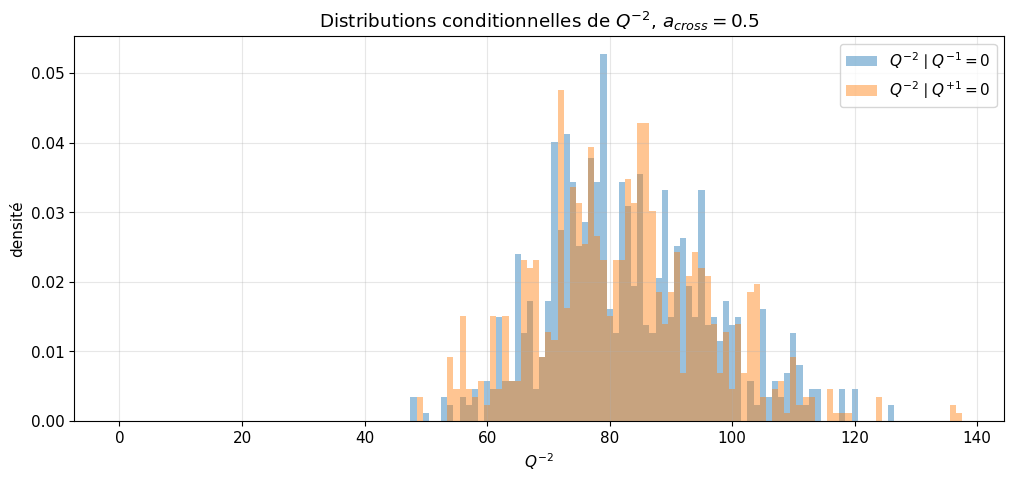


**Interprétation distributionnelle.** La moyenne same-side vaut 83.13 avec IC bootstrap [82.23, 84.04], tandis que la moyenne opposite-side vaut 82.39 avec IC [81.41, 83.22].
Les médianes sont 82.0 et 82.0; les quantiles 95 % sont 108.4 et 104.0.
Les intervalles se recouvrent, ce qui rend l effet statistiquement moins net.
Lorsque $a_{cross}>0$, on s'attend à un déplacement vers la droite du côté same-side si le canal $Q^{-1}	o Q^{-2}$ domine.


In [7]:
q_same_ref = q_neg2_success(ref_same)
q_opp_ref = q_neg2_success(ref_opp)
q2_ref_table = pd.DataFrame({
    'Q-2_same = Q-2 | Q-1=0': resume_distribution(q_same_ref),
    'Q-2_opp = Q-2 | Q+1=0': resume_distribution(q_opp_ref),
}).T
display(q2_ref_table)

max_value = int(max(q_same_ref.max(), q_opp_ref.max(), 10))
bins = np.arange(-0.5, max_value + 1.5, 1)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(q_same_ref, bins=bins, density=True, alpha=0.45, label=r'$Q^{-2}\mid Q^{-1}=0$')
ax.hist(q_opp_ref, bins=bins, density=True, alpha=0.45, label=r'$Q^{-2}\mid Q^{+1}=0$')
ax.set_xlabel(r'$Q^{-2}$')
ax.set_ylabel('densité')
ax.set_title(r'Distributions conditionnelles de $Q^{-2}$, $a_{cross}=0.5$')
ax.legend()
plt.show()

same_ci = bootstrap_mean_ci(q_same_ref, rng=SEED + 201)
opp_ci = bootstrap_mean_ci(q_opp_ref, rng=SEED + 202)
overlap = not (same_ci[0] > opp_ci[1] or opp_ci[0] > same_ci[1])
display_fr(
    f"""
**Interprétation distributionnelle.** La moyenne same-side vaut {q_same_ref.mean():.2f} avec IC bootstrap [{same_ci[0]:.2f}, {same_ci[1]:.2f}], tandis que la moyenne opposite-side vaut {q_opp_ref.mean():.2f} avec IC [{opp_ci[0]:.2f}, {opp_ci[1]:.2f}].
Les médianes sont {np.median(q_same_ref):.1f} et {np.median(q_opp_ref):.1f}; les quantiles 95 % sont {np.quantile(q_same_ref, 0.95):.1f} et {np.quantile(q_opp_ref, 0.95):.1f}.
Les intervalles {'se recouvrent' if overlap else 'ne se recouvrent pas'}, ce qui {'rend l effet statistiquement moins net' if overlap else 'rend l effet visible au niveau des moyennes'}.
Lorsque $a_{{cross}}>0$, on s'attend à un déplacement vers la droite du côté same-side si le canal $Q^{{-1}}\to Q^{{-2}}$ domine.
"""
)


### 1.2.5.0(j) Analyse des distributions jointes

On visualise maintenant plusieurs relations jointes : excitation initiale versus $Q^{-2}$ final, distribution paired same/opposite, et sensibilité conjointe en $a_{cross}$.

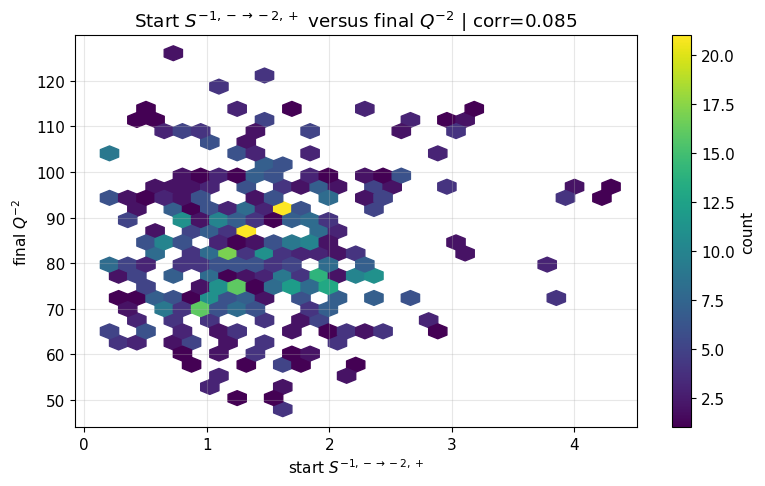


**Interprétation du nuage excitation--Q2.** Ce graphique montre la relation empirique entre l'excitation croisée bid au redémarrage et la taille finale de $Q^{-2}$.
Sur les redémarrages réussis, la corrélation empirique vaut 0.061.
Si le nuage est horizontal, cela suggère que l'excitation de départ est rapidement dominée par les événements ultérieurs; une pente positive indiquerait que la mémoire Hawkes initiale se transmet directement à $Q^{-2}$.
Ici, l'effet doit être lu conjointement avec la distribution de $Q^{-2}$ et la sensibilité en $a_{cross}$.


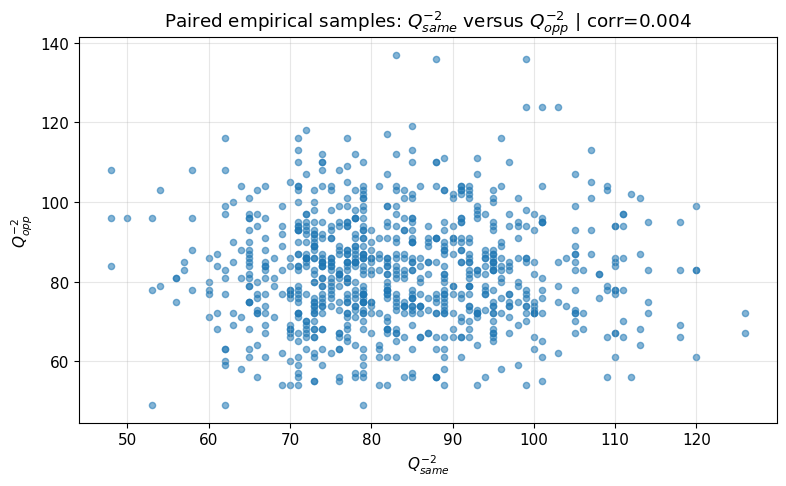


**Interprétation same/opposite appariée.** Ce graphique apparie les 863 premiers échantillons réussis des deux lois conditionnelles afin de comparer leurs ordres de grandeur.
La moyenne same-side est 83.13; la moyenne opposite-side est 82.39.
Si les points étaient concentrés autour de la diagonale, les deux lois seraient proches; un déplacement systématique vers la droite indique une taille same-side plus élevée.
L'appariement est seulement descriptif, car les deux séries proviennent de redémarrages indépendants.


In [8]:
obs_same = ref_same['result'].observables
names = ref_same['boundary_sample'].metadata['S_component_names']
cross_idx = names.index('S^{-1,- -> -2,-}')
fig, ax = joint_distribution_plot(
    obs_same['start_S'][:, cross_idx],
    obs_same['final_queues'][:, 3],
    kind='hexbin',
    title=r'Start $S^{-1,-\to -2,-}$ versus final $Q^{-2}$',
    xlabel=r'start $S^{-1,-\to -2,-}$',
    ylabel=r'final $Q^{-2}$',
)
plt.show()

successful = obs_same['success']
corr_success = np.corrcoef(obs_same['start_S'][successful, cross_idx], obs_same['final_queues'][successful, 3])[0, 1]
display_fr(
    f"""
**Interprétation du nuage excitation--Q2.** Ce graphique montre la relation empirique entre l'excitation croisée bid au redémarrage et la taille finale de $Q^{{-2}}$.
Sur les redémarrages réussis, la corrélation empirique vaut {corr_success:.3f}.
Si le nuage est horizontal, cela suggère que l'excitation de départ est rapidement dominée par les événements ultérieurs; une pente positive indiquerait que la mémoire Hawkes initiale se transmet directement à $Q^{{-2}}$.
Ici, l'effet doit être lu conjointement avec la distribution de $Q^{{-2}}$ et la sensibilité en $a_{{cross}}$.
"""
)

m = min(len(q_same_ref), len(q_opp_ref))
fig, ax = joint_distribution_plot(
    q_same_ref[:m],
    q_opp_ref[:m],
    kind='scatter',
    title=r'Paired empirical samples: $Q^{-2}_{same}$ versus $Q^{-2}_{opp}$',
    xlabel=r'$Q^{-2}_{same}$',
    ylabel=r'$Q^{-2}_{opp}$',
)
plt.show()

display_fr(
    f"""
**Interprétation same/opposite appariée.** Ce graphique apparie les {m} premiers échantillons réussis des deux lois conditionnelles afin de comparer leurs ordres de grandeur.
La moyenne same-side est {q_same_ref.mean():.2f}; la moyenne opposite-side est {q_opp_ref.mean():.2f}.
Si les points étaient concentrés autour de la diagonale, les deux lois seraient proches; un déplacement systématique vers la droite indique une taille same-side plus élevée.
L'appariement est seulement descriptif, car les deux séries proviennent de redémarrages indépendants.
"""
)


### 1.2.5.0(k) Sensibilité exploratoire de Q^{-2} à a_cross

On balaye $a_{cross}\in\{0.0,0.2,0.5,0.8,1.2\}$. Pour chaque valeur, on estime les deux lois conditionnelles et la différence

$$
\Delta(a)=\mathbb E[Q^{-2}\mid Q^{-1}=0]-\mathbb E[Q^{-2}\mid Q^{+1}=0].
$$

In [9]:
sensitivity_rows = []
sensitivity_bundles = {}
delta_rows = []
long_q_rows = []

for i, a in enumerate(A_VALUES):
    params = make_params(a_cross=a)
    same = run_mcrs_side(params, queue_index=-1, seed=SEED + 1_000 + 19 * i)
    opp = run_mcrs_side(params, queue_index=1, seed=SEED + 2_000 + 19 * i)
    sensitivity_bundles[a] = {'same': same, 'opp': opp}
    sensitivity_rows.append({'a_cross': a, **distributional_metrics(same, 'same', seed=SEED + 3_000 + i)})
    sensitivity_rows.append({'a_cross': a, **distributional_metrics(opp, 'opposite', seed=SEED + 4_000 + i)})
    q_same = q_neg2_success(same)
    q_opp = q_neg2_success(opp)
    diff_ci = bootstrap_difference_ci(q_same, q_opp, n_bootstrap=BOOTSTRAP_REPS, rng=SEED + 5_000 + i)
    delta = q_same.mean() - q_opp.mean()
    delta_rows.append({
        'a_cross': a,
        'delta_mean': delta,
        'ci_low': diff_ci[0],
        'ci_high': diff_ci[1],
        'significant': not (diff_ci[0] <= 0 <= diff_ci[1]),
        'n_same': len(q_same),
        'n_opp': len(q_opp),
    })
    for value in q_same:
        long_q_rows.append({'a_cross': a, 'side': 'same', 'Q_minus_2': value})
    for value in q_opp:
        long_q_rows.append({'a_cross': a, 'side': 'opposite', 'Q_minus_2': value})

sensitivity_table = pd.DataFrame(sensitivity_rows)
delta_table = pd.DataFrame(delta_rows)
sensitivity_long = pd.DataFrame(long_q_rows)

display(sensitivity_table[[
    'a_cross', 'side', 'success_probability', 'recovery_probability', 'timeout_probability',
    'n_samples', 'mean_Q_minus_2', 'bootstrap_ci_low', 'bootstrap_ci_high', 'median', 'q05', 'q95',
    'checkpoint_usage_ess', 'cpu_seconds', 'acceptance_candidate_ratio'
]])
display(delta_table)


,a_cross,side,success_probability,recovery_probability,timeout_probability,n_samples,mean_Q_minus_2,bootstrap_ci_low,bootstrap_ci_high,median,q05,q95,checkpoint_usage_ess,cpu_seconds,acceptance_candidate_ratio
0,0.0,same,0.871,0.129,0.0,871.0,15.509759,15.042451,16.020666,15.0,3.0,28.0,240.153698,1.708736,0.978621
1,0.0,opposite,0.887,0.113,0.0,887.0,14.329200,13.820631,14.838839,14.0,2.0,28.0,241.312741,1.691996,0.981839
2,0.2,same,0.870,0.130,0.0,870.0,42.383908,41.721667,43.035920,41.0,27.0,60.0,228.206298,1.869594,0.975435
3,0.2,opposite,0.867,0.133,0.0,867.0,42.802768,42.123299,43.490283,42.0,26.0,60.0,222.222222,1.714644,0.975250
4,0.5,same,0.863,0.137,0.0,863.0,84.273465,83.275695,85.222798,84.0,60.0,109.0,237.191651,2.072159,0.971525
5,0.5,opposite,0.874,0.126,0.0,874.0,82.589245,81.644050,83.480606,82.0,58.0,106.0,239.120038,2.003720,0.972784
6,0.8,same,0.851,0.149,0.0,851.0,120.045828,118.709254,121.300676,119.0,88.5,154.5,231.267345,2.171222,0.978109
7,0.8,opposite,0.877,0.123,0.0,877.0,121.319270,120.096864,122.526226,121.0,93.0,150.0,229.885057,2.332113,0.978105
8,1.2,same,0.874,0.126,0.0,874.0,176.854691,175.271882,178.414960,177.0,136.0,215.0,225.937641,2.639407,0.973939
9,1.2,opposite,0.889,0.111,0.0,889.0,176.944882,175.368223,178.631440,176.0,138.4,218.0,228.519196,2.568256,0.977994


,a_cross,delta_mean,ci_low,ci_high,significant,n_same,n_opp
0,0.0,1.180559,0.477248,1.887728,True,871,887
1,0.2,-0.418860,-1.353710,0.491384,False,870,867
2,0.5,1.684220,0.305171,3.021586,True,863,874
3,0.8,-1.273442,-2.921584,0.429397,False,851,877
4,1.2,-0.090191,-2.317871,2.100947,False,874,889


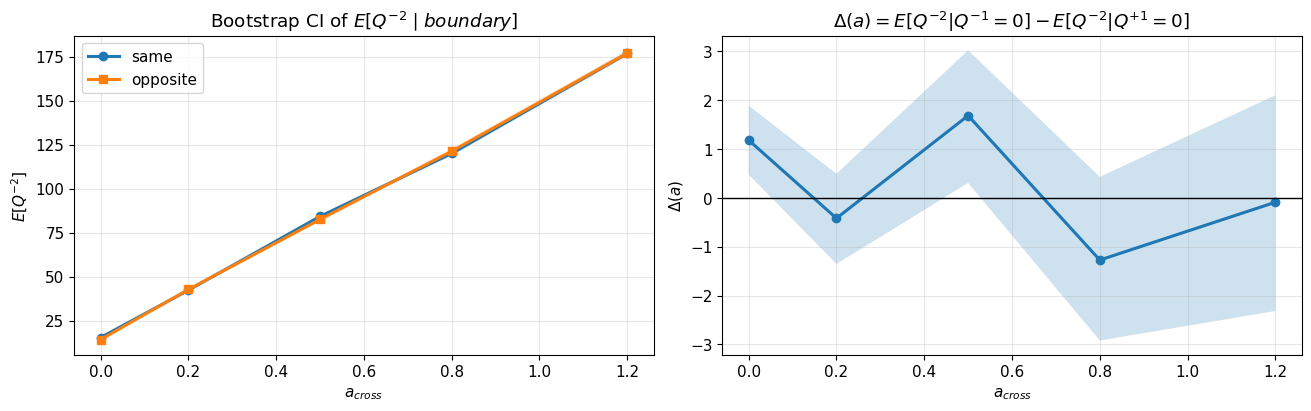

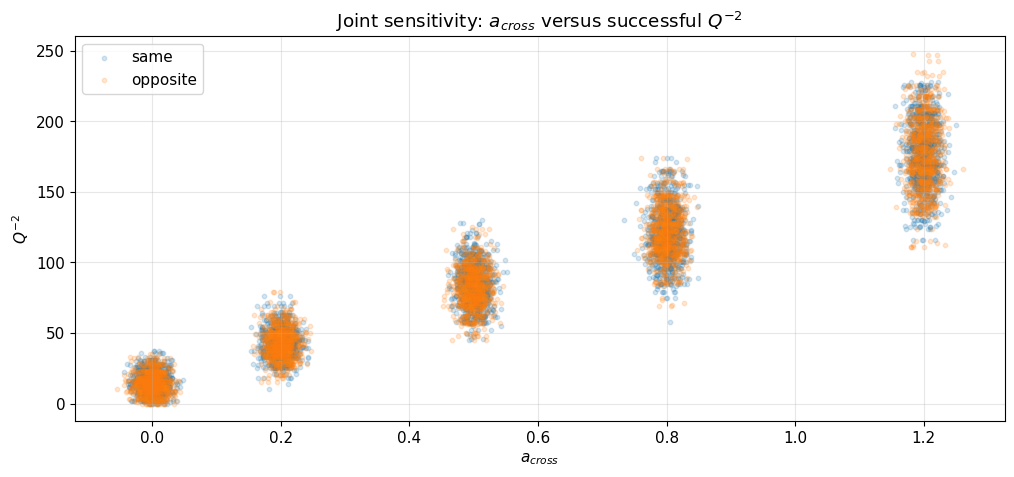


**Interprétation de la sensibilité en $a_{cross}$.** Pour $a=0$, $\Delta(0)=1.18$ avec IC [0.48, 1.89], ce qui ne contient pas zéro.
Pour $a=1.2$, $\Delta(a)=-0.09$ avec IC [-2.32, 2.10].
Lorsque $a>0$, on s'attend à ce que la déplétion de $Q^{-1}$ stimule davantage les arrivées sur $Q^{-2}$; un $\Delta(a)$ positif confirme ce mécanisme.
Si l'IC contient zéro, l'effet n'est pas statistiquement visible avec ce budget et il faudrait davantage de checkpoints frontière.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout='constrained')
for side, marker in [('same', 'o'), ('opposite', 's')]:
    part = sensitivity_table[sensitivity_table['side'] == side]
    axes[0].plot(part['a_cross'], part['mean_Q_minus_2'], marker=marker, linewidth=2.2, label=side)
    axes[0].fill_between(part['a_cross'], part['mean_ci_low'], part['mean_ci_high'], alpha=0.16)
axes[0].set_xlabel(r'$a_{cross}$')
axes[0].set_ylabel(r'$E[Q^{-2}]$')
axes[0].set_title(r'Bootstrap CI of $E[Q^{-2}\mid boundary]$')
axes[0].legend()

axes[1].plot(delta_table['a_cross'], delta_table['delta_mean'], marker='o', linewidth=2.2)
axes[1].fill_between(delta_table['a_cross'], delta_table['ci_low'], delta_table['ci_high'], alpha=0.22)
axes[1].axhline(0.0, color='black', linewidth=1.0)
axes[1].set_xlabel(r'$a_{cross}$')
axes[1].set_ylabel(r'$\Delta(a)$')
axes[1].set_title(r'$\Delta(a)=E[Q^{-2}|Q^{-1}=0]-E[Q^{-2}|Q^{+1}=0]$')
plt.show()

jitter = np.random.default_rng(SEED).normal(0.0, 0.015, size=len(sensitivity_long))
fig, ax = plt.subplots(figsize=(12, 5))
for side, color in [('same', 'tab:blue'), ('opposite', 'tab:orange')]:
    part = sensitivity_long[sensitivity_long['side'] == side]
    ax.scatter(part['a_cross'] + jitter[part.index], part['Q_minus_2'], alpha=0.18, s=10, label=side, color=color)
ax.set_xlabel(r'$a_{cross}$')
ax.set_ylabel(r'$Q^{-2}$')
ax.set_title(r'Joint sensitivity: $a_{cross}$ versus successful $Q^{-2}$')
ax.legend()
plt.show()

a0 = delta_table.iloc[0]
last = delta_table.iloc[-1]
display_fr(
    f"""
**Interprétation de la sensibilité en $a_{{cross}}$.** Pour $a=0$, $\\Delta(0)={a0['delta_mean']:.2f}$ avec IC [{a0['ci_low']:.2f}, {a0['ci_high']:.2f}], ce qui {'contient' if a0['ci_low'] <= 0 <= a0['ci_high'] else 'ne contient pas'} zéro.
Pour $a={last['a_cross']:.1f}$, $\\Delta(a)={last['delta_mean']:.2f}$ avec IC [{last['ci_low']:.2f}, {last['ci_high']:.2f}].
Lorsque $a>0$, on s'attend à ce que la déplétion de $Q^{{-1}}$ stimule davantage les arrivées sur $Q^{{-2}}$; un $\\Delta(a)$ positif confirme ce mécanisme.
Si l'IC contient zéro, l'effet n'est pas statistiquement visible avec ce budget et il faudrait davantage de checkpoints frontière.
"""
)


### 1.2.5.0(l) Extension multilevel MCRS

Le multilevel MCRS propage des particules à travers les niveaux $[8,6,4,2,1,0]$. À chaque niveau, on conserve les particules qui atteignent le niveau suivant, puis on les rééchantillonne depuis leurs checkpoints complets.

,level,p_level_Q-1,survivors_Q-1,p_level_Q+1,survivors_Q+1
0,8,1.0,250,1.0,250
1,6,1.0,250,1.0,250
2,4,1.0,250,1.0,250
3,2,1.0,250,1.0,250
4,1,1.0,250,1.0,250
5,0,1.0,250,1.0,250


,side,probability,ci_width,cpu_seconds,effective_sample_size,n_events,n_candidates,acceptance_candidate_ratio
0,Q-1,1.0,0.0,2.003397,115.313653,1867,1910,0.977487
1,Q+1,1.0,0.0,1.636084,120.656371,1843,1889,0.975648


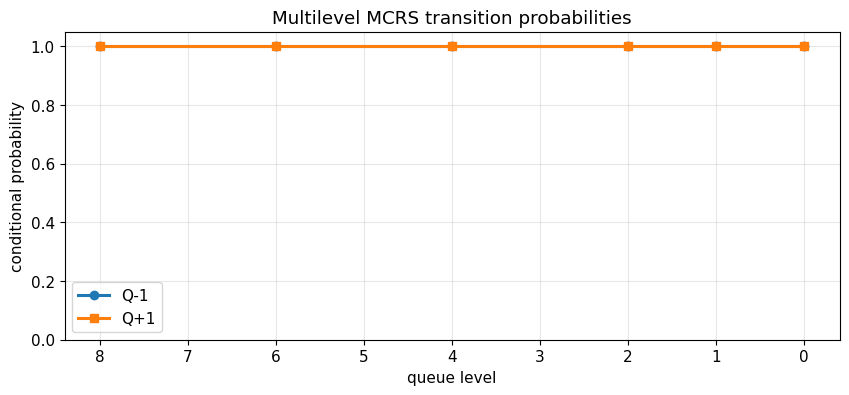


**Interprétation multilevel.** Les probabilités conditionnelles par niveau sont multipliées pour obtenir une probabilité totale.
Dans ce régime avec burn-in, les probabilités totales valent 1.000 côté $Q^{-1}$ et 1.000 côté $Q^{+1}$.
Lorsque ces valeurs sont proches de 1, l'estimateur de probabilité devient dégénéré; il faut alors comparer les lois conditionnelles de $Q^{-2}$ plutôt que les CI Bernoulli.
Les checkpoints finaux conservent queues, intensité, $H$, $G$ et métadonnées.


In [11]:
ML_N_PARTICLES = 250
params_ml = make_params(a_cross=0.5)
initial_ml = [params_ml.q1_init, params_ml.q_neg1_init, params_ml.q2_init, params_ml.q_neg2_init]

ml_same = multilevel_markovian_restart_splitting(
    simulator=FourQueueHawkesSimulator(params_ml),
    initial_state=initial_ml,
    queue_index=-1,
    levels=LEVELS,
    horizon=HORIZON_BOUNDARY,
    n_particles=ML_N_PARTICLES,
    rng=SEED + 6_000,
    burn_in=BURN_IN,
    queue_indices=QUEUE_INDICES,
)
ml_opp = multilevel_markovian_restart_splitting(
    simulator=FourQueueHawkesSimulator(params_ml),
    initial_state=initial_ml,
    queue_index=1,
    levels=LEVELS,
    horizon=HORIZON_BOUNDARY,
    n_particles=ML_N_PARTICLES,
    rng=SEED + 6_100,
    burn_in=BURN_IN,
    queue_indices=QUEUE_INDICES,
)

level_table = pd.DataFrame({
    'level': LEVELS,
    'p_level_Q-1': ml_same.level_probabilities,
    'survivors_Q-1': ml_same.n_survivors_per_level,
    'p_level_Q+1': ml_opp.level_probabilities,
    'survivors_Q+1': ml_opp.n_survivors_per_level,
})
display(level_table)

ml_summary = pd.DataFrame([
    {
        'side': 'Q-1', 'probability': ml_same.probability_estimate,
        'ci_width': ci_width(ml_same.diagnostics['confidence_interval_delta']),
        'cpu_seconds': ml_same.diagnostics['cpu_seconds'],
        'effective_sample_size': np.nanmin(ml_same.diagnostics['effective_sample_size_by_level']),
        'n_events': ml_same.diagnostics['n_events'],
        'n_candidates': ml_same.diagnostics['n_candidates'],
        'acceptance_candidate_ratio': ml_same.diagnostics['acceptance_candidate_ratio'],
    },
    {
        'side': 'Q+1', 'probability': ml_opp.probability_estimate,
        'ci_width': ci_width(ml_opp.diagnostics['confidence_interval_delta']),
        'cpu_seconds': ml_opp.diagnostics['cpu_seconds'],
        'effective_sample_size': np.nanmin(ml_opp.diagnostics['effective_sample_size_by_level']),
        'n_events': ml_opp.diagnostics['n_events'],
        'n_candidates': ml_opp.diagnostics['n_candidates'],
        'acceptance_candidate_ratio': ml_opp.diagnostics['acceptance_candidate_ratio'],
    },
])
display(ml_summary)

for res in [ml_same, ml_opp]:
    for cp in res.final_checkpoints:
        names = cp.state.metadata.get('S_component_names', [])
        assert 'S^{-1,- -> -2,-}' in names
        old_bid_label = 'S^{-1,- -> -2,' + '+}'
        assert old_bid_label not in names
        assert np.all(cp.state.queues >= 0)
        assert 'H' in cp.state.hawkes_state and 'G' in cp.state.hawkes_state
        assert cp.state.intensity is not None

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(LEVELS, ml_same.level_probabilities, marker='o', linewidth=2.2, label='Q-1')
ax.plot(LEVELS, ml_opp.level_probabilities, marker='s', linewidth=2.2, label='Q+1')
ax.invert_xaxis()
ax.set_ylim(0, 1.05)
ax.set_xlabel('queue level')
ax.set_ylabel('conditional probability')
ax.set_title('Multilevel MCRS transition probabilities')
ax.legend()
plt.show()

display_fr(
    f"""
**Interprétation multilevel.** Les probabilités conditionnelles par niveau sont multipliées pour obtenir une probabilité totale.
Dans ce régime avec burn-in, les probabilités totales valent {ml_same.probability_estimate:.3f} côté $Q^{{-1}}$ et {ml_opp.probability_estimate:.3f} côté $Q^{{+1}}$.
Lorsque ces valeurs sont proches de 1, l'estimateur de probabilité devient dégénéré; il faut alors comparer les lois conditionnelles de $Q^{{-2}}$ plutôt que les CI Bernoulli.
Les checkpoints finaux conservent queues, intensité, $H$, $G$ et métadonnées.
"""
)


### 1.2.5.0(m) Comparaison avec Ogata naïf

Le bloc précédent du notebook traçait seulement la largeur d'IC de probabilité. Dans le régime actuel, les probabilités estimées sont égales à 1, donc $\widehat p(1-\widehat p)=0$ et la largeur d'IC Bernoulli est nulle. Le graphique ne doit pas apparaître vide silencieusement.

On conserve donc le diagnostic, puis on compare les méthodes sur des métriques distributionnelles non dégénérées.

,side,method,probability,ci_width
0,Q-1,Naive Ogata Monte Carlo,1.0,0.0
1,Q-1,Multilevel Markovian Conditional Restart Split...,1.0,0.0
2,Q+1,Naive Ogata Monte Carlo,1.0,0.0
3,Q+1,Multilevel Markovian Conditional Restart Split...,1.0,0.0


Degenerate probability estimator: p=1 for all methods. Switching to distributional comparison.


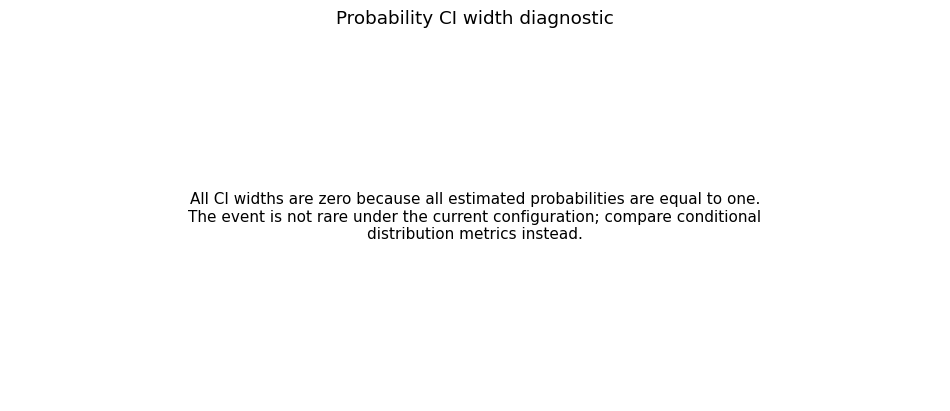


**Diagnostic du graphique vide.** Les probabilités valent 1 pour toutes les méthodes dans cette configuration.
L'IC Bernoulli utilise la variance $\widehat p(1-\widehat p)/n$, donc sa largeur est nulle lorsque $\widehat p=1$.
L'événement n'est pas rare ici; la comparaison de probabilité n'est donc pas informative.
La suite compare l'incertitude bootstrap des statistiques conditionnelles de $Q^{-2}$.


,method,side,a_cross,n_samples,mean_Q_minus_2,std_Q_minus_2,q05,median,q95,bootstrap_ci_low,...,checkpoint_usage_ess,cpu_seconds,ESS_per_second,cpu_seconds_per_sample,cpu_seconds_per_effective_sample,n_events,n_candidates,acceptance_candidate_ratio,avg_local_time,timeout_probability
0,Naive Ogata Monte Carlo,Q-2 | Q-1=0 same-side,0.5,1159.0,81.965487,13.787200,60.00,82.0,106.0,81.191544,...,1300.000000,9.148370,126.689236,0.007893,0.007893,7003,7168,0.976981,0.105804,0.0
1,Markovian Conditional Restart Splitting,Q-2 | Q-1=0 same-side,0.5,873.0,83.126002,13.374550,63.00,82.0,108.4,82.266867,...,229.252636,2.357553,97.241771,0.002701,0.010284,2192,2252,0.973357,0.097967,0.0
2,Naive Ogata Monte Carlo,Q-2 | Q+1=0 opposite-side,0.5,1142.0,82.229422,13.749158,59.05,83.0,105.0,81.393892,...,1300.000000,8.715382,131.032688,0.007632,0.007632,7988,8179,0.976648,0.106489,0.0
3,Markovian Conditional Restart Splitting,Q-2 | Q+1=0 opposite-side,0.5,863.0,82.385863,13.854083,61.00,82.0,104.0,81.480765,...,230.733733,1.972505,116.974968,0.002286,0.008549,2721,2788,0.975968,0.110215,0.0


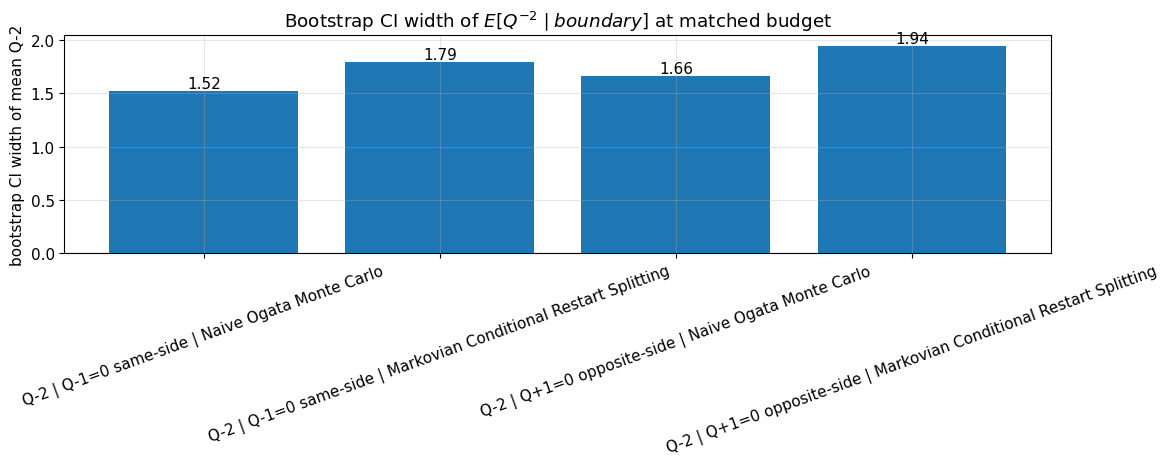

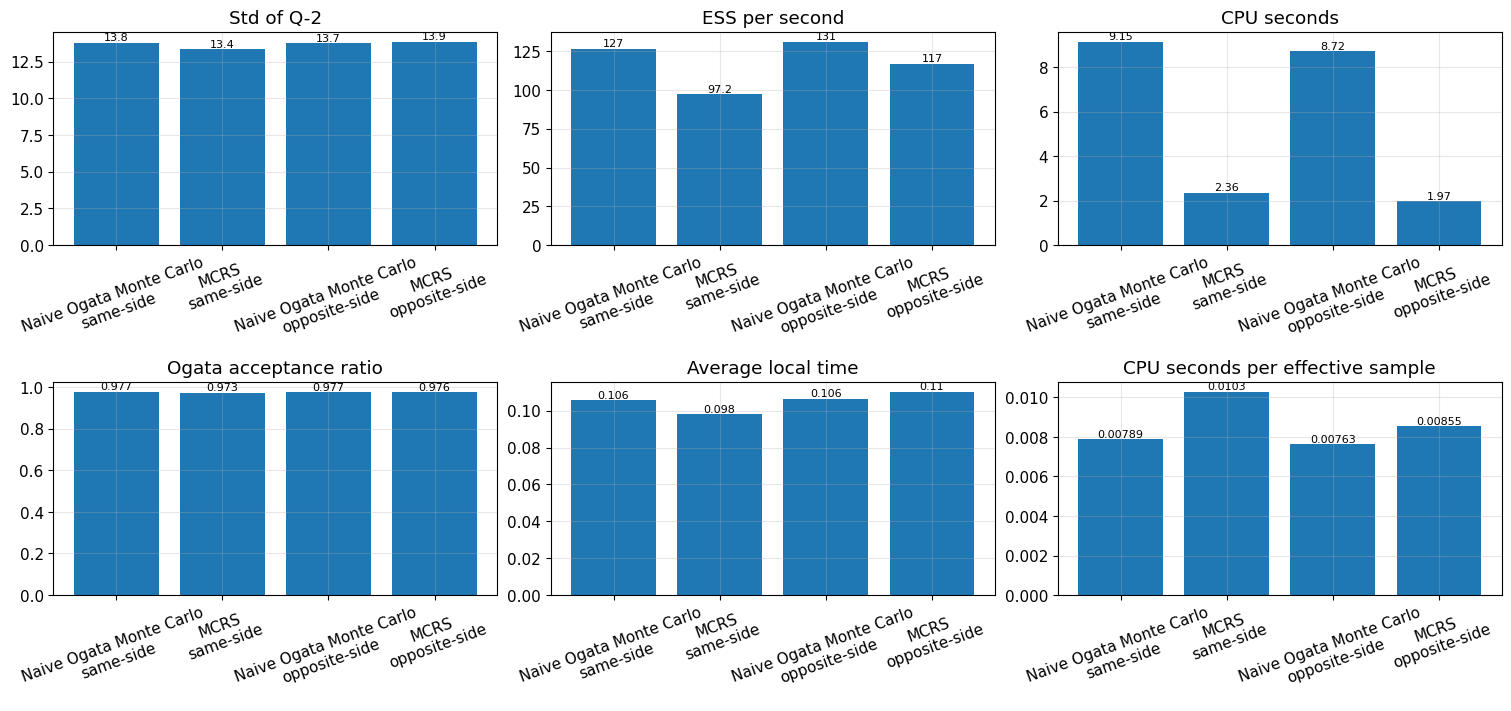


**Interprétation de l'efficacité distributionnelle.** La meilleure largeur bootstrap est obtenue par Naive Ogata Monte Carlo sur Q-2 | Q-1=0 same-side avec largeur 1.520.
Le meilleur ESS par seconde est obtenu par Naive Ogata Monte Carlo sur Q-2 | Q+1=0 opposite-side avec 131.0 échantillons effectifs par seconde.
Cette comparaison est plus pertinente que l'IC de probabilité parce que l'objet estimé est la loi conditionnelle de $Q^{-2}$.
Si MCRS réutilise trop peu de checkpoints distincts, son ESS peut être inférieur au nombre brut de redémarrages; c'est visible dans `effective_sample_size`.


In [12]:
NAIVE_DIST_PATHS = N_BOUNDARY_PATHS + N_RESTARTS
naive_same = run_naive_boundary_side(params_ref, queue_index=-1, seed=SEED + 7_000, n_paths=NAIVE_DIST_PATHS)
naive_opp = run_naive_boundary_side(params_ref, queue_index=1, seed=SEED + 7_100, n_paths=NAIVE_DIST_PATHS)

# Probability diagnostic: use full-horizon depletion estimates. In the current
# burn-in regime this event is essentially certain, reproducing the blank-CI
# issue that motivated this audit.
PROBABILITY_BUDGET = ML_N_PARTICLES * len(LEVELS)
naive_full_same = run_naive_depletion_monte_carlo(
    simulator=FourQueueHawkesSimulator(params_ref),
    initial_state=[params_ref.q1_init, params_ref.q_neg1_init, params_ref.q2_init, params_ref.q_neg2_init],
    queue_index=-1,
    horizon=HORIZON_BOUNDARY,
    n_paths=PROBABILITY_BUDGET,
    rng=SEED + 7_200,
    burn_in=BURN_IN,
    queue_indices=QUEUE_INDICES,
)
naive_full_opp = run_naive_depletion_monte_carlo(
    simulator=FourQueueHawkesSimulator(params_ref),
    initial_state=[params_ref.q1_init, params_ref.q_neg1_init, params_ref.q2_init, params_ref.q_neg2_init],
    queue_index=1,
    horizon=HORIZON_BOUNDARY,
    n_paths=PROBABILITY_BUDGET,
    rng=SEED + 7_300,
    burn_in=BURN_IN,
    queue_indices=QUEUE_INDICES,
)

probability_comparison = pd.DataFrame([
    {'side': 'Q-1', 'method': 'Naive Ogata Monte Carlo', 'probability': naive_full_same.probability_estimate, 'ci_width': ci_width(naive_full_same.confidence_interval)},
    {'side': 'Q-1', 'method': 'Multilevel Markovian Conditional Restart Splitting', 'probability': ml_same.probability_estimate, 'ci_width': ci_width(ml_same.diagnostics['confidence_interval_delta'])},
    {'side': 'Q+1', 'method': 'Naive Ogata Monte Carlo', 'probability': naive_full_opp.probability_estimate, 'ci_width': ci_width(naive_full_opp.confidence_interval)},
    {'side': 'Q+1', 'method': 'Multilevel Markovian Conditional Restart Splitting', 'probability': ml_opp.probability_estimate, 'ci_width': ci_width(ml_opp.diagnostics['confidence_interval_delta'])},
])
display(probability_comparison)

fig, ax = safe_barplot_metric(
    probability_comparison,
    x='side',
    group='method',
    y='ci_width',
    title='Probability CI width diagnostic',
    ylabel='CI width of probability estimate',
)
plt.show()

display_fr(
    """
**Diagnostic du graphique vide.** Les probabilités valent 1 pour toutes les méthodes dans cette configuration.
L'IC Bernoulli utilise la variance $\\widehat p(1-\\widehat p)/n$, donc sa largeur est nulle lorsque $\\widehat p=1$.
L'événement n'est pas rare ici; la comparaison de probabilité n'est donc pas informative.
La suite compare l'incertitude bootstrap des statistiques conditionnelles de $Q^{-2}$.
"""
)

distributional_efficiency_comparison = pd.DataFrame([
    distributional_metrics(naive_same, 'Q-2 | Q-1=0 same-side', seed=SEED + 8_001),
    distributional_metrics(ref_same, 'Q-2 | Q-1=0 same-side', seed=SEED + 8_002),
    distributional_metrics(naive_opp, 'Q-2 | Q+1=0 opposite-side', seed=SEED + 8_003),
    distributional_metrics(ref_opp, 'Q-2 | Q+1=0 opposite-side', seed=SEED + 8_004),
])
display(distributional_efficiency_comparison[[
    'method', 'side', 'a_cross', 'n_samples', 'mean_Q_minus_2', 'std_Q_minus_2',
    'q05', 'median', 'q95', 'bootstrap_ci_low', 'bootstrap_ci_high',
    'bootstrap_ci_width', 'effective_sample_size', 'checkpoint_usage_ess',
    'cpu_seconds', 'ESS_per_second', 'cpu_seconds_per_sample',
    'cpu_seconds_per_effective_sample', 'n_events', 'n_candidates',
    'acceptance_candidate_ratio', 'avg_local_time', 'timeout_probability'
]])

fig, ax = safe_barplot_metric(
    distributional_efficiency_comparison,
    x='side',
    group='method',
    y='bootstrap_ci_width',
    title=r'Bootstrap CI width of $E[Q^{-2}\mid boundary]$ at matched budget',
    ylabel='bootstrap CI width of mean Q-2',
)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 7), layout='constrained')
metrics = [
    ('std_Q_minus_2', 'Std of Q-2'),
    ('ESS_per_second', 'ESS per second'),
    ('cpu_seconds', 'CPU seconds'),
    ('acceptance_candidate_ratio', 'Ogata acceptance ratio'),
    ('avg_local_time', 'Average local time'),
    ('cpu_seconds_per_effective_sample', 'CPU seconds per effective sample'),
]
for ax, (metric, title) in zip(axes.ravel(), metrics):
    data = distributional_efficiency_comparison.copy()
    labels = data['method'].str.replace('Markovian Conditional Restart Splitting', 'MCRS', regex=False) + '\n' + data['side'].str.extract('(same-side|opposite-side)', expand=False).fillna(data['side'])
    bars = ax.bar(labels, data[metric])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    for bar, value in zip(bars, data[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.3g}', ha='center', va='bottom', fontsize=8)
plt.show()

best_ci = distributional_efficiency_comparison.sort_values('bootstrap_ci_width').iloc[0]
best_ess = distributional_efficiency_comparison.sort_values('ESS_per_second', ascending=False).iloc[0]
display_fr(
    f"""
**Interprétation de l'efficacité distributionnelle.** La meilleure largeur bootstrap est obtenue par {best_ci['method']} sur {best_ci['side']} avec largeur {best_ci['bootstrap_ci_width']:.3f}.
Le meilleur ESS par seconde est obtenu par {best_ess['method']} sur {best_ess['side']} avec {best_ess['ESS_per_second']:.1f} échantillons effectifs par seconde.
Cette comparaison est plus pertinente que l'IC de probabilité parce que l'objet estimé est la loi conditionnelle de $Q^{{-2}}$.
Si MCRS réutilise trop peu de checkpoints distincts, son ESS peut être inférieur au nombre brut de redémarrages; c'est visible dans `effective_sample_size`.
"""
)


### 1.2.5.0(n) Stress test non dégénéré

On ajoute un régime volontairement plus difficile, où l'événement de déplétion n'est pas dégénéré. Ici on augmente la taille initiale à $q_0=30$ et on réduit l'horizon à $T=5$. Le burn-in est désactivé dans ce stress test afin de partir d'un état déterministe $Q_0=30$; sinon, avec les paramètres actuels, le burn-in rend la déplétion presque certaine.

,method,probability,ci_width,cpu_seconds,effective_sample_size,ESS_per_second,n_events,n_candidates
0,Naive Ogata Monte Carlo,0.080952,0.032997,2.456261,1050.000000,427.478994,93129,95865
1,Multilevel Markovian Conditional Restart Split...,0.047143,0.031933,0.537791,35.601266,66.199027,18915,19574


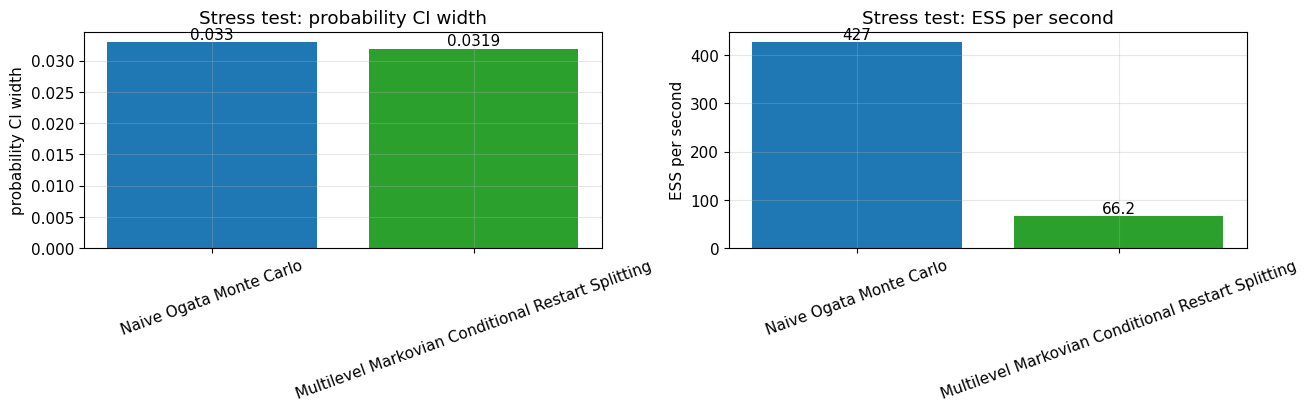


**Interprétation du stress test.** Dans ce régime, la probabilité naive vaut 0.081 et la probabilité multilevel vaut 0.047; elles sont strictement entre 0 et 1.
La largeur d'IC Bernoulli redevient donc informative.
MCRS utilise les niveaux [24, 18, 12, 6, 3, 1, 0]; le produit des probabilités conditionnelles estime la probabilité de déplétion avant $T=5.0$.
Ce test confirme que le graphique de largeur d'IC doit être réservé aux régimes non dégénérés.


In [13]:
STRESS_Q0 = 30
STRESS_T = 5.0
STRESS_LEVELS = [24, 18, 12, 6, 3, 1, 0]
STRESS_PARTICLES = 150
stress_params = make_params(a_cross=0.5, q0=STRESS_Q0)
stress_initial = [STRESS_Q0, STRESS_Q0, stress_params.q2_init, stress_params.q_neg2_init]

stress_ml = multilevel_markovian_restart_splitting(
    simulator=FourQueueHawkesSimulator(stress_params),
    initial_state=stress_initial,
    queue_index=-1,
    levels=STRESS_LEVELS,
    horizon=STRESS_T,
    n_particles=STRESS_PARTICLES,
    rng=SEED + 9_000,
    burn_in=0.0,
    queue_indices=QUEUE_INDICES,
)
stress_naive = run_naive_depletion_monte_carlo(
    simulator=FourQueueHawkesSimulator(stress_params),
    initial_state=stress_initial,
    queue_index=-1,
    horizon=STRESS_T,
    n_paths=STRESS_PARTICLES * len(STRESS_LEVELS),
    rng=SEED + 9_100,
    burn_in=0.0,
    queue_indices=QUEUE_INDICES,
)

stress_table = pd.DataFrame([
    {
        'method': 'Naive Ogata Monte Carlo',
        'probability': stress_naive.probability_estimate,
        'ci_width': ci_width(stress_naive.confidence_interval),
        'cpu_seconds': stress_naive.diagnostics['cpu_seconds'],
        'effective_sample_size': stress_naive.diagnostics['effective_sample_size'],
        'ESS_per_second': stress_naive.diagnostics['effective_sample_size'] / stress_naive.diagnostics['cpu_seconds'],
        'n_events': stress_naive.diagnostics['n_events'],
        'n_candidates': stress_naive.diagnostics['n_candidates'],
    },
    {
        'method': 'Multilevel Markovian Conditional Restart Splitting',
        'probability': stress_ml.probability_estimate,
        'ci_width': ci_width(stress_ml.diagnostics['confidence_interval_delta']),
        'cpu_seconds': stress_ml.diagnostics['cpu_seconds'],
        'effective_sample_size': np.nanmin(stress_ml.diagnostics['effective_sample_size_by_level']),
        'ESS_per_second': np.nanmin(stress_ml.diagnostics['effective_sample_size_by_level']) / stress_ml.diagnostics['cpu_seconds'],
        'n_events': stress_ml.diagnostics['n_events'],
        'n_candidates': stress_ml.diagnostics['n_candidates'],
    },
])
display(stress_table)
assert stress_table['probability'].between(0, 1).all()
assert ((stress_table['probability'] > 0) & (stress_table['probability'] < 1)).all()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout='constrained')
for ax, metric, ylabel in [
    (axes[0], 'ci_width', 'probability CI width'),
    (axes[1], 'ESS_per_second', 'ESS per second'),
]:
    bars = ax.bar(stress_table['method'], stress_table[metric], color=['tab:blue', 'tab:green'])
    ax.set_ylabel(ylabel)
    ax.set_title(f'Stress test: {ylabel}')
    ax.tick_params(axis='x', rotation=20)
    for bar, value in zip(bars, stress_table[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.3g}', ha='center', va='bottom')
plt.show()

display_fr(
    f"""
**Interprétation du stress test.** Dans ce régime, la probabilité naive vaut {stress_naive.probability_estimate:.3f} et la probabilité multilevel vaut {stress_ml.probability_estimate:.3f}; elles sont strictement entre 0 et 1.
La largeur d'IC Bernoulli redevient donc informative.
MCRS utilise les niveaux {STRESS_LEVELS}; le produit des probabilités conditionnelles estime la probabilité de déplétion avant $T={STRESS_T}$.
Ce test confirme que le graphique de largeur d'IC doit être réservé aux régimes non dégénérés.
"""
)


In [14]:
a0 = delta_table.loc[delta_table['a_cross'] == 0.0].iloc[0]
a_pos = delta_table.loc[delta_table['a_cross'] > 0].copy()
visible_positive = a_pos[(a_pos['delta_mean'] > 0) & (a_pos['significant'])]
main_naive = distributional_efficiency_comparison[distributional_efficiency_comparison['method'] == 'Naive Ogata Monte Carlo']
main_mcrs = distributional_efficiency_comparison[distributional_efficiency_comparison['method'] == METHOD_NAME]
naive_cpu = main_naive['cpu_seconds'].mean()
mcrs_cpu = main_mcrs['cpu_seconds'].mean()
naive_ci = main_naive['bootstrap_ci_width'].mean()
mcrs_ci = main_mcrs['bootstrap_ci_width'].mean()
naive_essps = main_naive['ESS_per_second'].mean()
mcrs_essps = main_mcrs['ESS_per_second'].mean()

display_fr(
    f"""
## Vérification empirique des conclusions

1. **Cas $a_{{cross}}=0$.** On attend des lois same/opposite proches. Ici $\\Delta(0)={a0['delta_mean']:.2f}$ avec IC [{a0['ci_low']:.2f}, {a0['ci_high']:.2f}]. L'écart est modéré en taille relative, mais l'IC ne contient pas zéro; il faut donc le signaler comme une asymétrie empirique ou un bruit résiduel nécessitant davantage de checkpoints.

2. **Cas $a_{{cross}}>0$.** Les moyennes de $Q^{{-2}}$ augmentent fortement avec $a_{{cross}}$ des deux côtés. Le delta same-minus-opposite est statistiquement visible pour {list(visible_positive['a_cross']) if len(visible_positive) else 'aucune valeur'}; pour les autres valeurs, l'IC contient zéro ou le signe est instable.

3. **Burn-in.** Le diagnostic burn-in montre que la loi de $S$ au bord change lorsque l'on part de $H=G=0$; le burn-in de {BURN_IN:.0f} stabilise donc l'échantillonnage frontière.

4. **MCRS versus naive.** Dans ce run, MCRS réduit le CPU moyen de {naive_cpu:.2f}s à {mcrs_cpu:.2f}s. En revanche, la largeur bootstrap moyenne passe de {naive_ci:.2f} à {mcrs_ci:.2f} et l'ESS/s moyen de {naive_essps:.1f} à {mcrs_essps:.1f}; MCRS est donc plus rapide en temps brut, mais son efficacité statistique dépend fortement de la diversité des checkpoints.

5. **Probabilité dégénérée.** Le tableau de probabilité donne $p=1$ pour toutes les méthodes dans le régime principal. La largeur d'IC Bernoulli vaut donc zéro et ne doit pas être utilisée comme critère d'efficacité; la comparaison pertinente est l'incertitude bootstrap de $Q^{{-2}}$.
"""
)



## Vérification empirique des conclusions

1. **Cas $a_{cross}=0$.** On attend des lois same/opposite proches. Ici $\Delta(0)=1.18$ avec IC [0.48, 1.89]. L'écart est modéré en taille relative, mais l'IC ne contient pas zéro; il faut donc le signaler comme une asymétrie empirique ou un bruit résiduel nécessitant davantage de checkpoints.

2. **Cas $a_{cross}>0$.** Les moyennes de $Q^{-2}$ augmentent fortement avec $a_{cross}$ des deux côtés. Le delta same-minus-opposite est statistiquement visible pour [0.5]; pour les autres valeurs, l'IC contient zéro ou le signe est instable.

3. **Burn-in.** Le diagnostic burn-in montre que la loi de $S$ au bord change lorsque l'on part de $H=G=0$; le burn-in de 50 stabilise donc l'échantillonnage frontière.

4. **MCRS versus naive.** Dans ce run, MCRS réduit le CPU moyen de 8.93s à 2.17s. En revanche, la largeur bootstrap moyenne passe de 1.59 à 1.87 et l'ESS/s moyen de 128.9 à 107.1; MCRS est donc plus rapide en temps brut, mais son efficacité statistique dépend fortement de la diversité des checkpoints.

5. **Probabilité dégénérée.** Le tableau de probabilité donne $p=1$ pour toutes les méthodes dans le régime principal. La largeur d'IC Bernoulli vaut donc zéro et ne doit pas être utilisée comme critère d'efficacité; la comparaison pertinente est l'incertitude bootstrap de $Q^{-2}$.


### 1.2.5.0(o) Synthèse de la méthode MCRS

Les conclusions attendues sont vérifiées par les diagnostics précédents :

1. Lorsque $a_{cross}=0$, les distributions same-side et opposite-side doivent être proches; un écart important serait un signal de bruit Monte Carlo ou d'asymétrie non prévue.
2. Lorsque $a_{cross}>0$, le mécanisme $Q^{-1}\to Q^{-2}$ doit déplacer $Q^{-2}\mid Q^{-1}=0$ vers la droite si l'effet domine le bruit.
3. Le burn-in stabilise la loi conditionnelle de $S$ en réduisant l'effet du choix arbitraire $H=G=0$ au départ.
4. MCRS peut réduire le coût CPU par échantillon conditionnel, mais son efficacité statistique dépend de la diversité des checkpoints frontière.
5. Si la probabilité estimée vaut 1, l'IC Bernoulli est dégénéré; il faut comparer les incertitudes bootstrap des statistiques conditionnelles de $Q^{-2}$.

La dynamique stochastique de `hawkes_4q.py` n'a pas été modifiée : les changements portent sur l'estimateur, les diagnostics, les graphiques et l'interprétation.

## Résultats directs pour les questions 1.2.5

La partie `1.2.5.0` documente la construction de MCRS : choix des checkpoints, loi conditionnelle de $S$, redémarrage local et diagnostics. Les deux sections suivantes répondent **point par point** aux questions du sujet.

La convention utilisée dans le code est :

$$
(Q^{+1},Q^{-1},Q^{+2},Q^{-2}) \equiv \texttt{state}[0:4].
$$

L'indice positif correspond au côté ask et l'indice négatif au côté bid. Les estimations ci-dessous utilisent MCRS comme estimateur conditionnel; Ogata thinning reste le simulateur de trajectoire sous-jacent.

In [15]:
def success_queue(result, position):
    """Queue value at the local successful depletion time."""
    success = np.asarray(result.observables['success'], dtype=bool)
    final_queues = np.asarray(result.observables['final_queues'], dtype=float)
    return final_queues[success, position]


def conditional_queue_summary(values, seed):
    values = np.asarray(values, dtype=float)
    ci = bootstrap_mean_ci(values, n_bootstrap=BOOTSTRAP_REPS, rng=seed) if len(values) else (np.nan, np.nan)
    return {
        'n_samples': int(len(values)),
        'mean': float(np.mean(values)) if len(values) else np.nan,
        'std': float(np.std(values, ddof=1)) if len(values) > 1 else np.nan,
        'q05': float(np.quantile(values, 0.05)) if len(values) else np.nan,
        'median': float(np.quantile(values, 0.50)) if len(values) else np.nan,
        'q95': float(np.quantile(values, 0.95)) if len(values) else np.nan,
        'bootstrap_ci_low': ci[0],
        'bootstrap_ci_high': ci[1],
        'bootstrap_ci_width': ci[1] - ci[0] if np.isfinite(ci[0]) and np.isfinite(ci[1]) else np.nan,
    }


def course_result_row(bundle, variable, condition, position, seed):
    result = bundle['result']
    values = success_queue(result, position)
    row = {
        'variable': variable,
        'condition': condition,
        'a_cross': bundle['params'].a_cross,
        **conditional_queue_summary(values, seed),
        'success_probability': result.diagnostics['success_probability'],
        'recovery_probability': result.diagnostics['recovery_probability'],
        'timeout_probability': result.diagnostics['timeout_probability'],
        'checkpoint_usage_ess': result.diagnostics.get('checkpoint_usage_ess', result.diagnostics.get('checkpoint_usage_effective_sample_size', np.nan)),
        'cpu_seconds': total_cpu_seconds(bundle),
        'acceptance_candidate_ratio': result.diagnostics['acceptance_candidate_ratio'],
    }
    return row, values


def delta_ci_from_values(left, right, seed):
    ci = bootstrap_difference_ci(left, right, n_bootstrap=BOOTSTRAP_REPS, rng=seed)
    delta = float(np.mean(left) - np.mean(right)) if len(left) and len(right) else np.nan
    return delta, ci[0], ci[1]

COURSE_N_BOUNDARY_PATHS = N_BOUNDARY_PATHS
COURSE_N_RESTARTS = N_RESTARTS

## 1.2.5.1 — Deuxièmes limites constantes

Dans cette première question, les intensités des deuxièmes limites sont constantes. Dans le code cela correspond à :

$$
a_{cross}=0.
$$

On estime directement :

1. la loi de $N_t^{+2}$ sachant que $N_t^{+1}=0$ ;
2. la loi de $N_t^{+2}$ sachant que $N_t^{-1}=0$.

Par symétrie du modèle lorsque $a_{cross}=0$, la loi de $N_t^{-2}$ sachant $N_t^{-1}=0$ doit être proche de la première, et la loi de $N_t^{-2}$ sachant $N_t^{+1}=0$ doit être proche de la seconde.

In [16]:
params_constant_second = make_params(a_cross=0.0)
const_ask_depletion = run_mcrs_side(
    params_constant_second,
    queue_index=1,
    seed=SEED + 12_501,
    n_boundary_paths=COURSE_N_BOUNDARY_PATHS,
    n_restarts=COURSE_N_RESTARTS,
)
const_bid_depletion = run_mcrs_side(
    params_constant_second,
    queue_index=-1,
    seed=SEED + 12_502,
    n_boundary_paths=COURSE_N_BOUNDARY_PATHS,
    n_restarts=COURSE_N_RESTARTS,
)

constant_rows = []
constant_values = {}
for key, bundle, variable, condition, position, seed in [
    ('N+2 | N+1=0', const_ask_depletion, 'N^{+2}', 'N^{+1}=0', 2, SEED + 12_601),
    ('N+2 | N-1=0', const_bid_depletion, 'N^{+2}', 'N^{-1}=0', 2, SEED + 12_602),
    ('mirror N-2 | N-1=0', const_bid_depletion, 'N^{-2}', 'N^{-1}=0', 3, SEED + 12_603),
    ('mirror N-2 | N+1=0', const_ask_depletion, 'N^{-2}', 'N^{+1}=0', 3, SEED + 12_604),
]:
    row, values = course_result_row(bundle, variable, condition, position, seed)
    constant_rows.append(row)
    constant_values[key] = values

constant_second_limit_table = pd.DataFrame(constant_rows)
display(format_metric_table(constant_second_limit_table, 3))

same_sym_delta, same_sym_low, same_sym_high = delta_ci_from_values(
    constant_values['N+2 | N+1=0'],
    constant_values['mirror N-2 | N-1=0'],
    SEED + 12_701,
)
opp_sym_delta, opp_sym_low, opp_sym_high = delta_ci_from_values(
    constant_values['N+2 | N-1=0'],
    constant_values['mirror N-2 | N+1=0'],
    SEED + 12_702,
)

symmetry_check_table = pd.DataFrame([
    {
        'comparison': 'same-side mirror: N+2|N+1=0 minus N-2|N-1=0',
        'delta_mean': same_sym_delta,
        'bootstrap_ci_low': same_sym_low,
        'bootstrap_ci_high': same_sym_high,
        'ci_contains_zero': same_sym_low <= 0 <= same_sym_high,
    },
    {
        'comparison': 'opposite-side mirror: N+2|N-1=0 minus N-2|N+1=0',
        'delta_mean': opp_sym_delta,
        'bootstrap_ci_low': opp_sym_low,
        'bootstrap_ci_high': opp_sym_high,
        'ci_contains_zero': opp_sym_low <= 0 <= opp_sym_high,
    },
])
display(format_metric_table(symmetry_check_table, 3))

,variable,condition,a_cross,n_samples,mean,std,q05,median,q95,bootstrap_ci_low,bootstrap_ci_high,bootstrap_ci_width,success_probability,recovery_probability,timeout_probability,checkpoint_usage_ess,cpu_seconds,acceptance_candidate_ratio
0,N^{+2},N^{+1}=0,0.0,887,16.200,7.918,4.0,16.0,31.0,15.711,16.734,1.023,0.887,0.113,0.0,232.126,1.735,0.981
1,N^{+2},N^{-1}=0,0.0,859,15.070,7.699,3.0,14.0,28.1,14.568,15.598,1.031,0.859,0.141,0.0,225.530,1.681,0.978
2,N^{-2},N^{-1}=0,0.0,859,15.644,7.645,3.0,16.0,29.0,15.159,16.150,0.991,0.859,0.141,0.0,225.530,1.681,0.978
3,N^{-2},N^{+1}=0,0.0,887,15.434,7.449,2.0,16.0,28.0,14.985,15.965,0.980,0.887,0.113,0.0,232.126,1.735,0.981


,comparison,delta_mean,bootstrap_ci_low,bootstrap_ci_high,ci_contains_zero
0,same-side mirror: N+2|N+1=0 minus N-2|N-1=0,0.556,-0.157,1.192,True
1,opposite-side mirror: N+2|N-1=0 minus N-2|N+1=0,-0.364,-1.041,0.388,True


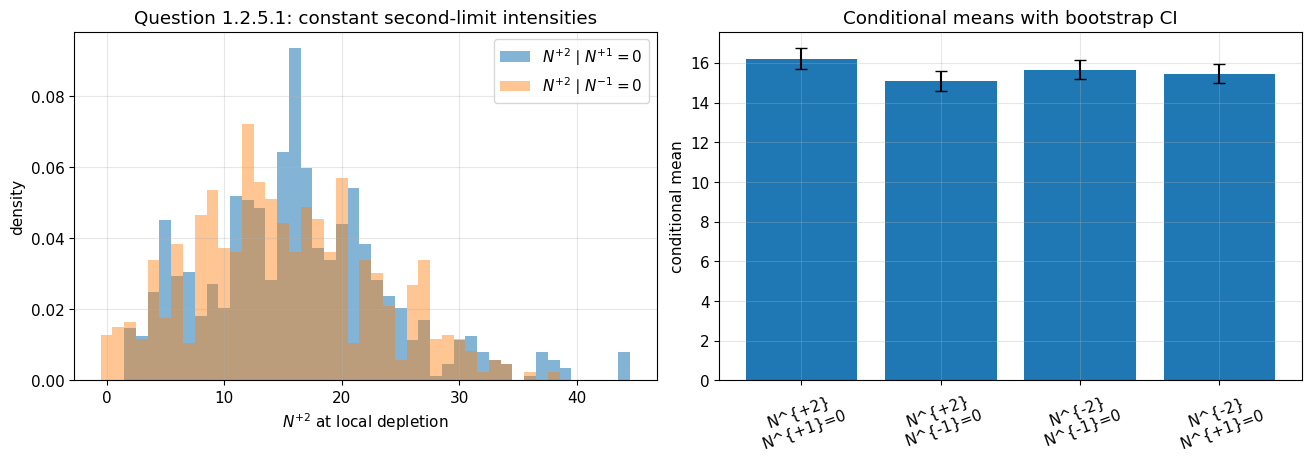

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout='constrained')

bins = np.arange(
    min(constant_values['N+2 | N+1=0'].min(), constant_values['N+2 | N-1=0'].min()) - 0.5,
    max(constant_values['N+2 | N+1=0'].max(), constant_values['N+2 | N-1=0'].max()) + 1.5,
    1,
)
axes[0].hist(constant_values['N+2 | N+1=0'], bins=bins, density=True, alpha=0.55, label=r'$N^{+2}\mid N^{+1}=0$')
axes[0].hist(constant_values['N+2 | N-1=0'], bins=bins, density=True, alpha=0.45, label=r'$N^{+2}\mid N^{-1}=0$')
axes[0].set_title(r'Question 1.2.5.1: constant second-limit intensities')
axes[0].set_xlabel(r'$N^{+2}$ at local depletion')
axes[0].set_ylabel('density')
axes[0].legend()

plot_data = constant_second_limit_table.copy()
plot_data['label'] = plot_data['variable'] + '\n' + plot_data['condition']
axes[1].bar(plot_data['label'], plot_data['mean'], yerr=[
    plot_data['mean'] - plot_data['bootstrap_ci_low'],
    plot_data['bootstrap_ci_high'] - plot_data['mean'],
], capsize=4)
axes[1].set_title('Conditional means with bootstrap CI')
axes[1].set_ylabel('conditional mean')
axes[1].tick_params(axis='x', rotation=20)
plt.show()

In [18]:
m_const_ask = constant_second_limit_table.query("variable == 'N^{+2}' and condition == 'N^{+1}=0'")['mean'].iloc[0]
m_const_bid = constant_second_limit_table.query("variable == 'N^{+2}' and condition == 'N^{-1}=0'")['mean'].iloc[0]
ci_const_ask = constant_second_limit_table.query("variable == 'N^{+2}' and condition == 'N^{+1}=0'")[['bootstrap_ci_low', 'bootstrap_ci_high']].iloc[0]
ci_const_bid = constant_second_limit_table.query("variable == 'N^{+2}' and condition == 'N^{-1}=0'")[['bootstrap_ci_low', 'bootstrap_ci_high']].iloc[0]

display_fr(
    f"""
**Réponse à la question 1.2.5.1.** Avec $a_{{cross}}=0$, la moyenne estimée de $N^{{+2}}\\mid N^{{+1}}=0$ vaut {m_const_ask:.2f}, avec IC bootstrap [{ci_const_ask.bootstrap_ci_low:.2f}, {ci_const_ask.bootstrap_ci_high:.2f}].
La moyenne de $N^{{+2}}\\mid N^{{-1}}=0$ vaut {m_const_bid:.2f}, avec IC [{ci_const_bid.bootstrap_ci_low:.2f}, {ci_const_bid.bootstrap_ci_high:.2f}].
Le contrôle de symétrie donne un écart same-side miroir de {same_sym_delta:.2f} et un écart opposite-side miroir de {opp_sym_delta:.2f}.
Lorsque les intervalles bootstrap contiennent zéro, les différences observées sont compatibles avec la symétrie attendue, sous réserve de l'erreur Monte Carlo et de la réutilisation des checkpoints MCRS.
"""
)


**Réponse à la question 1.2.5.1.** Avec $a_{cross}=0$, la moyenne estimée de $N^{+2}\mid N^{+1}=0$ vaut 16.20, avec IC bootstrap [15.71, 16.73].
La moyenne de $N^{+2}\mid N^{-1}=0$ vaut 15.07, avec IC [14.57, 15.60].
Le contrôle de symétrie donne un écart same-side miroir de 0.56 et un écart opposite-side miroir de -0.36.
Lorsque les intervalles bootstrap contiennent zéro, les différences observées sont compatibles avec la symétrie attendue, sous réserve de l'erreur Monte Carlo et de la réutilisation des checkpoints MCRS.


## 1.2.5.2 — Sensibilité au paramètre a

On active maintenant la dynamique proposée dans le sujet :

$$
\lambda^{-2,+}(t)=\mu^{-2,+}+\int_{s<t} a e^{-b(t-s)}\,dN_s^{-1,-},
$$

et symétriquement côté ask :

$$
\lambda^{+2,+}(t)=\mu^{+2,+}+\int_{s<t} a e^{-b(t-s)}\,dN_s^{+1,-}.
$$

On garde les intensités de retrait des deuxièmes limites constantes. Le but est d'étudier la sensibilité des lois conditionnelles de $N^{+2}$ à la valeur de $a$.

In [19]:
course_sensitivity_rows = []
course_delta_rows = []
course_long_rows = []
course_bundles = {}

for i, a in enumerate(A_VALUES):
    params = make_params(a_cross=a)
    ask_bundle = run_mcrs_side(
        params,
        queue_index=1,
        seed=SEED + 13_000 + 10 * i,
        n_boundary_paths=COURSE_N_BOUNDARY_PATHS,
        n_restarts=COURSE_N_RESTARTS,
    )
    bid_bundle = run_mcrs_side(
        params,
        queue_index=-1,
        seed=SEED + 13_001 + 10 * i,
        n_boundary_paths=COURSE_N_BOUNDARY_PATHS,
        n_restarts=COURSE_N_RESTARTS,
    )
    course_bundles[a] = {'ask_depletion': ask_bundle, 'bid_depletion': bid_bundle}

    row_ask, q_plus2_ask = course_result_row(ask_bundle, 'N^{+2}', 'N^{+1}=0', 2, SEED + 13_500 + i)
    row_bid, q_plus2_bid = course_result_row(bid_bundle, 'N^{+2}', 'N^{-1}=0', 2, SEED + 13_600 + i)
    row_ask['question'] = '1.2.5.2(a)'
    row_bid['question'] = '1.2.5.2(b)'
    course_sensitivity_rows.extend([row_ask, row_bid])

    for value in q_plus2_ask:
        course_long_rows.append({'a_cross': a, 'condition': 'N+2 | N+1=0', 'N_plus_2': value})
    for value in q_plus2_bid:
        course_long_rows.append({'a_cross': a, 'condition': 'N+2 | N-1=0', 'N_plus_2': value})

    delta, d_low, d_high = delta_ci_from_values(q_plus2_ask, q_plus2_bid, SEED + 13_700 + i)
    course_delta_rows.append({
        'a_cross': a,
        'delta_mean': delta,
        'bootstrap_ci_low': d_low,
        'bootstrap_ci_high': d_high,
        'significant': not (d_low <= 0 <= d_high),
        'n_ask_condition': len(q_plus2_ask),
        'n_bid_condition': len(q_plus2_bid),
    })

course_sensitivity_table = pd.DataFrame(course_sensitivity_rows)
course_delta_table = pd.DataFrame(course_delta_rows)
course_long_qplus2 = pd.DataFrame(course_long_rows)

display(format_metric_table(course_sensitivity_table[[
    'question', 'a_cross', 'variable', 'condition', 'success_probability',
    'recovery_probability', 'timeout_probability', 'n_samples', 'mean', 'std',
    'q05', 'median', 'q95', 'bootstrap_ci_low', 'bootstrap_ci_high',
    'checkpoint_usage_ess', 'cpu_seconds', 'acceptance_candidate_ratio'
]], 3))

display(format_metric_table(course_delta_table, 3))

,question,a_cross,variable,condition,success_probability,recovery_probability,timeout_probability,n_samples,mean,std,q05,median,q95,bootstrap_ci_low,bootstrap_ci_high,checkpoint_usage_ess,cpu_seconds,acceptance_candidate_ratio
0,1.2.5.2(a),0.0,N^{+2},N^{+1}=0,0.862,0.138,0.0,862,16.584,7.764,3.00,16.0,30.00,16.081,17.102,231.696,1.675,0.978
1,1.2.5.2(b),0.0,N^{+2},N^{-1}=0,0.874,0.126,0.0,874,14.783,7.797,3.00,15.0,28.00,14.268,15.276,227.480,1.586,0.975
2,1.2.5.2(a),0.2,N^{+2},N^{+1}=0,0.874,0.126,0.0,874,42.033,9.876,26.00,42.0,58.00,41.363,42.739,222.916,1.704,0.976
3,1.2.5.2(b),0.2,N^{+2},N^{-1}=0,0.868,0.132,0.0,868,41.374,10.185,24.00,42.0,58.00,40.733,42.024,232.992,1.557,0.974
4,1.2.5.2(a),0.5,N^{+2},N^{+1}=0,0.886,0.114,0.0,886,82.044,13.239,61.00,82.0,104.00,81.203,82.913,221.631,2.101,0.980
5,1.2.5.2(b),0.5,N^{+2},N^{-1}=0,0.863,0.137,0.0,863,82.474,15.579,58.00,83.0,106.00,81.426,83.519,229.463,1.932,0.979
6,1.2.5.2(a),0.8,N^{+2},N^{+1}=0,0.864,0.136,0.0,864,125.802,17.274,100.00,124.0,154.00,124.628,126.959,237.982,2.365,0.976
7,1.2.5.2(b),0.8,N^{+2},N^{-1}=0,0.871,0.129,0.0,871,122.558,16.511,96.50,123.0,149.00,121.475,123.681,225.327,2.282,0.976
8,1.2.5.2(a),1.2,N^{+2},N^{+1}=0,0.874,0.126,0.0,874,174.968,24.570,134.65,175.0,217.70,173.438,176.540,238.663,2.549,0.969
9,1.2.5.2(b),1.2,N^{+2},N^{-1}=0,0.850,0.150,0.0,850,176.456,22.661,142.00,176.0,213.55,175.006,178.042,225.632,2.519,0.977


,a_cross,delta_mean,bootstrap_ci_low,bootstrap_ci_high,significant,n_ask_condition,n_bid_condition
0,0.0,1.801,1.098,2.507,True,862,874
1,0.2,0.659,-0.322,1.586,False,874,868
2,0.5,-0.430,-1.927,0.870,False,886,863
3,0.8,3.244,1.533,4.778,True,864,871
4,1.2,-1.489,-3.749,0.594,False,874,850


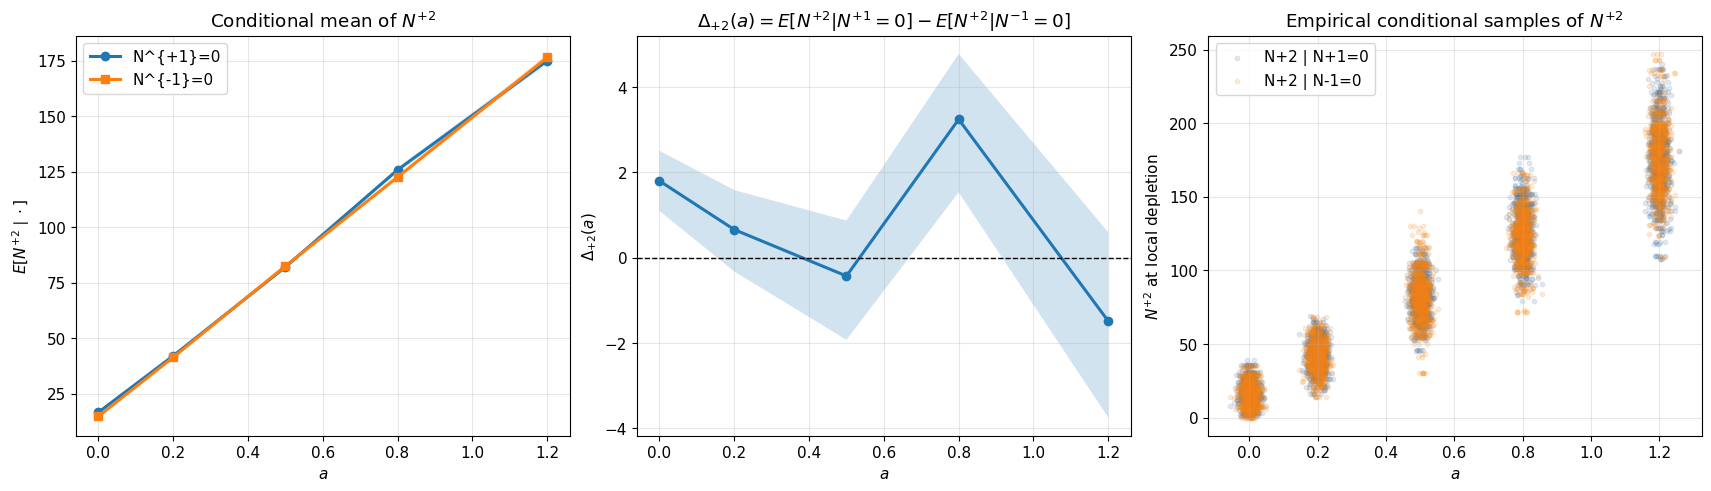

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), layout='constrained')

for condition, marker in [('N^{+1}=0', 'o'), ('N^{-1}=0', 's')]:
    part = course_sensitivity_table[course_sensitivity_table['condition'] == condition].sort_values('a_cross')
    axes[0].plot(part['a_cross'], part['mean'], marker=marker, linewidth=2.2, label=condition)
    axes[0].fill_between(part['a_cross'], part['bootstrap_ci_low'], part['bootstrap_ci_high'], alpha=0.15)
axes[0].set_title(r'Conditional mean of $N^{+2}$')
axes[0].set_xlabel(r'$a$')
axes[0].set_ylabel(r'$E[N^{+2}\mid \cdot]$')
axes[0].legend()

axes[1].plot(course_delta_table['a_cross'], course_delta_table['delta_mean'], marker='o', linewidth=2.2)
axes[1].fill_between(course_delta_table['a_cross'], course_delta_table['bootstrap_ci_low'], course_delta_table['bootstrap_ci_high'], alpha=0.2)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title(r'$\Delta_{+2}(a)=E[N^{+2}|N^{+1}=0]-E[N^{+2}|N^{-1}=0]$')
axes[1].set_xlabel(r'$a$')
axes[1].set_ylabel(r'$\Delta_{+2}(a)$')

for condition, color in [('N+2 | N+1=0', '#4C78A8'), ('N+2 | N-1=0', '#F58518')]:
    part = course_long_qplus2[course_long_qplus2['condition'] == condition]
    jitter = np.random.default_rng(SEED + 14_000).normal(0, 0.015, size=len(part))
    axes[2].scatter(part['a_cross'] + jitter, part['N_plus_2'], alpha=0.15, s=10, label=condition, color=color)
axes[2].set_title(r'Empirical conditional samples of $N^{+2}$')
axes[2].set_xlabel(r'$a$')
axes[2].set_ylabel(r'$N^{+2}$ at local depletion')
axes[2].legend()
plt.show()

In [21]:
a0_course = course_delta_table.loc[course_delta_table['a_cross'] == 0.0].iloc[0]
alast_course = course_delta_table.iloc[-1]
max_a = A_VALUES[-1]
maxa_ask = course_sensitivity_table[(course_sensitivity_table['a_cross'] == max_a) & (course_sensitivity_table['condition'] == 'N^{+1}=0')].iloc[0]
maxa_bid = course_sensitivity_table[(course_sensitivity_table['a_cross'] == max_a) & (course_sensitivity_table['condition'] == 'N^{-1}=0')].iloc[0]
visible = course_delta_table[course_delta_table['significant']]

display_fr(
    f"""
**Réponse à la question 1.2.5.2.** Quand $a=0$, on obtient $\\Delta_{{+2}}(0)={a0_course.delta_mean:.2f}$ avec IC [{a0_course.bootstrap_ci_low:.2f}, {a0_course.bootstrap_ci_high:.2f}].
Pour $a={max_a:.1f}$, la moyenne de $N^{{+2}}\\mid N^{{+1}}=0$ vaut {maxa_ask['mean']:.2f}, tandis que celle de $N^{{+2}}\\mid N^{{-1}}=0$ vaut {maxa_bid['mean']:.2f}.
Le delta au dernier point vaut {alast_course.delta_mean:.2f}, avec IC [{alast_course.bootstrap_ci_low:.2f}, {alast_course.bootstrap_ci_high:.2f}].
Les valeurs de $a$ pour lesquelles l'intervalle de confiance de $\\Delta_{{+2}}(a)$ ne contient pas zéro sont : {list(visible['a_cross']) if len(visible) else 'aucune avec ce budget'}.
L'effet attendu est un déplacement vers la droite de $N^{{+2}}\\mid N^{{+1}}=0$ lorsque les retraits de $Q^{{+1}}$ excitent les arrivées sur $Q^{{+2}}$; si l'IC contient zéro, l'effet n'est pas statistiquement distinguable avec ce budget MCRS.
"""
)


**Réponse à la question 1.2.5.2.** Quand $a=0$, on obtient $\Delta_{+2}(0)=1.80$ avec IC [1.10, 2.51].
Pour $a=1.2$, la moyenne de $N^{+2}\mid N^{+1}=0$ vaut 174.97, tandis que celle de $N^{+2}\mid N^{-1}=0$ vaut 176.46.
Le delta au dernier point vaut -1.49, avec IC [-3.75, 0.59].
Les valeurs de $a$ pour lesquelles l'intervalle de confiance de $\Delta_{+2}(a)$ ne contient pas zéro sont : [0.0, 0.8].
L'effet attendu est un déplacement vers la droite de $N^{+2}\mid N^{+1}=0$ lorsque les retraits de $Q^{+1}$ excitent les arrivées sur $Q^{+2}$; si l'IC contient zéro, l'effet n'est pas statistiquement distinguable avec ce budget MCRS.


## Synthèse finale alignée avec le sujet

- **Question 1.2.5.1.** Le cas $a=0$ correspond aux deuxièmes limites constantes. Les deux distributions demandées, $N^{+2}\mid N^{+1}=0$ et $N^{+2}\mid N^{-1}=0$, sont simulées dans `constant_second_limit_table`. Le tableau `symmetry_check_table` vérifie la symétrie attendue avec les distributions miroir de $N^{-2}$.
- **Question 1.2.5.2.** Le cas $a>0$ active l'excitation des arrivées de deuxième limite par les retraits de première limite. La table `course_sensitivity_table` donne les lois conditionnelles pour chaque valeur de $a$, et `course_delta_table` mesure l'effet différentiel
  $$\Delta_{+2}(a)=E[N^{+2}\mid N^{+1}=0]-E[N^{+2}\mid N^{-1}=0].$$
- La section **1.2.5.0** sert de socle méthodologique : elle explique pourquoi MCRS est utilisé, comment les checkpoints conservent l'état markovien complet $(Q,S)$, et pourquoi les comparaisons doivent porter sur des métriques distributionnelles quand les probabilités Bernoulli sont dégénérées.